# **Import all the library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **load all csv files**
The dataset contains multiple CSV files stored inside a ZIP folder. First, the ZIP file is extracted into a separate directory. Then, all CSV files are identified and loaded individually using Pandas. The stock name is added as a new column, and finally, all individual datasets are combined into one master DataFrame for further data cleaning, exploratory data analysis, and feature engineering.
(yaha ham dataset ko drive me save bhi kiyae hai ,so baar baar zip import na krna pde)

In [ ]:
# ZIP → Extract → Find CSVs → Load CSVs

# Import required libraries
import zipfile
import os
import pandas as pd

# Path of the uploaded ZIP file
zip_path = "/content/archive (4).zip"

# Create a folder where all files from the ZIP will be extracted
extract_path = "/content/nifty50_data"

# Extract all files from the ZIP folder
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Find all CSV files inside the extracted folder
csv_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

# Display the total number of CSV files found
print("Total CSV files:", len(csv_files))

# Display the first 5 CSV file paths
print(csv_files[:5])

Total CSV files: 52
['/content/nifty50_data/TATASTEEL.csv', '/content/nifty50_data/HEROMOTOCO.csv', '/content/nifty50_data/HDFCBANK.csv', '/content/nifty50_data/NESTLEIND.csv', '/content/nifty50_data/BAJFINANCE.csv']


In [ ]:
# Create an empty list to store data from each CSV file
df_list = []

# Read each CSV file one by one
for file in csv_files:

    # Load the current CSV file into a DataFrame
    temp = pd.read_csv(file)

    # Extract the stock name from the filename
    temp["Stock"] = os.path.splitext(os.path.basename(file))[0]

    # Add the DataFrame to our list
    df_list.append(temp)

# Combine all individual stock DataFrames into one master DataFrame
df = pd.concat(df_list, ignore_index=True)

# Check the number of rows and columns
print("Shape of master dataset:", df.shape)

# Display the first 5 rows
df.head()


Shape of master dataset: (470434, 19)


/tmp/ipykernel_2436/2157685226.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(df_list, ignore_index=True)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Stock,Company Name,Industry,ISIN Code
0,2000-01-03,TISCO,EQ,142.35,148.00,153.2,146.10,152.50,152.45,150.92,2003185.0,3.023164e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
1,2000-01-04,TISCO,EQ,152.45,150.10,153.0,143.05,151.95,150.80,151.03,1555136.0,2.348785e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
2,2000-01-05,TISCO,EQ,150.80,144.60,162.9,144.60,158.00,156.55,156.85,3840284.0,6.023364e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
3,2000-01-06,TISCO,EQ,156.55,158.95,169.1,158.95,169.00,168.25,167.61,2560449.0,4.291530e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
4,2000-01-07,TISCO,EQ,168.25,173.40,179.0,166.30,170.55,171.95,173.89,3641691.0,6.332459e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN


In [ ]:
# Save the current master dataset permanently in Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os

# Create project folder
project_path = "/content/drive/MyDrive/Nifty50_Project"
os.makedirs(project_path, exist_ok=True)

# Save DataFrame
file_path = f"{project_path}/nifty50_master.parquet"

df.to_parquet(file_path, index=False)

print("Dataset saved successfully!")
print("Location:", file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset saved successfully!
Location: /content/drive/MyDrive/Nifty50_Project/nifty50_master.parquet


In [ ]:
# ==========================================
# BASIC DATASET UNDERSTANDING
# ==========================================

# 1. Check rows and columns
print("Dataset Shape:", df.shape)

# 2. Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# 3. Display first 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# 4. Display dataset information
print("\nDataset Information:")
df.info()

# 5. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 6. Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# 7. Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# 8. Number of unique stocks
print("\nNumber of Unique Stocks:", df["Stock"].nunique())


Dataset Shape: (470434, 19)

Column Names:
['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'Stock', 'Company Name', 'Industry', 'ISIN Code']

First 5 Rows:


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Stock,Company Name,Industry,ISIN Code
0,2000-01-03,TISCO,EQ,142.35,148.00,153.2,146.10,152.50,152.45,150.92,2003185.0,3.023164e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
1,2000-01-04,TISCO,EQ,152.45,150.10,153.0,143.05,151.95,150.80,151.03,1555136.0,2.348785e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
2,2000-01-05,TISCO,EQ,150.80,144.60,162.9,144.60,158.00,156.55,156.85,3840284.0,6.023364e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
3,2000-01-06,TISCO,EQ,156.55,158.95,169.1,158.95,169.00,168.25,167.61,2560449.0,4.291530e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN
4,2000-01-07,TISCO,EQ,168.25,173.40,179.0,166.30,170.55,171.95,173.89,3641691.0,6.332459e+13,NaN,NaN,NaN,TATASTEEL,NaN,NaN,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470434 entries, 0 to 470433
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                470384 non-null  object 
 1   Symbol              470434 non-null  object 
 2   Series              470434 non-null  object 
 3   Prev Close          470384 non-null  float64
 4   Open                470384 non-null  float64
 5   High                470384 non-null  float64
 6   Low                 470384 non-null  float64
 7   Last                470384 non-null  float64
 8   Close               470384 non-null  float64
 9   VWAP                470384 non-null  float64
 10  Volume              470384 non-null  float64
 11  Turnover            470384 non-null  float64
 12  Trades              240688 non-null  float64
 13  Deliverable Volume  438230 non-null  float64
 14  %Deliverble         438230 non-null  float64
 15  Stock       

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,470384.000000,470384.000000,470384.000000,470384.000000,470384.000000,470384.000000,470384.000000,4.703840e+05,4.703840e+05,2.406880e+05,4.382300e+05,438230.000000
mean,1266.196349,1267.759708,1286.581440,1247.488465,1266.388302,1266.554351,1267.132300,3.045903e+06,1.610138e+14,6.196427e+04,1.315098e+06,0.502997
std,2581.367576,2585.256861,2619.646432,2546.618689,2581.389799,2582.138197,2582.697234,7.333973e+06,3.298082e+14,6.866443e+04,2.831667e+06,0.190019
min,0.000000,8.500000,9.750000,8.500000,9.100000,9.150000,9.210000,3.000000e+00,1.047000e+07,1.100000e+01,5.000000e+00,0.023600
25%,274.300000,275.000000,279.500000,269.600000,274.400000,274.350000,274.697500,2.190095e+05,1.612816e+13,2.183400e+04,1.253825e+05,0.364700
50%,566.500000,567.025000,576.900000,556.500000,567.000000,566.700000,566.940000,1.010938e+06,6.832603e+13,4.406800e+04,5.017560e+05,0.511000
75%,1242.200000,1243.312500,1263.000000,1221.650000,1242.900000,1242.400000,1242.662500,3.019851e+06,1.863835e+14,7.893550e+04,1.452238e+06,0.638400
max,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.240000,4.810589e+08,3.564334e+16,1.643015e+06,2.325307e+08,1.000000



Number of Unique Stocks: 51




```

# **Handle Missing value** **bold text**

# **part1 handle missing value**

In [ ]:
df.isnull().sum()     # see the no. of missing value in each column

,0
Date,50
Symbol,0
Series,0
Prev Close,50
Open,50
High,50
Low,50
Last,50
Close,50
VWAP,50


In [ ]:
df[df["Date"].isnull()].head(10)

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Stock,Company Name,Industry,ISIN Code
376031,NaN,ADANIPORTS,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
376032,NaN,ASIANPAINT,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Asian Paints Ltd.,CONSUMER GOODS,INE021A01026
376033,NaN,AXISBANK,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Axis Bank Ltd.,FINANCIAL SERVICES,INE238A01034
376034,NaN,BAJAJ-AUTO,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Bajaj Auto Ltd.,AUTOMOBILE,INE917I01010
376035,NaN,BAJAJFINSV,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Bajaj Finserv Ltd.,FINANCIAL SERVICES,INE918I01018
376036,NaN,BAJFINANCE,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Bajaj Finance Ltd.,FINANCIAL SERVICES,INE296A01024
376037,NaN,BHARTIARTL,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Bharti Airtel Ltd.,TELECOM,INE397D01024
376038,NaN,BPCL,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Bharat Petroleum Corporation Ltd.,ENERGY,INE029A01011
376039,NaN,BRITANNIA,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Britannia Industries Ltd.,CONSUMER GOODS,INE216A01030
376040,NaN,CIPLA,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stock_metadata,Cipla Ltd.,PHARMA,INE059A01026


In [ ]:
df[df["Date"].isnull()].shape

(50, 19)

In [ ]:
df[df["Date"].isnull()][
    ["Symbol", "Stock", "Date", "Open", "High", "Low", "Close"]
]

,Symbol,Stock,Date,Open,High,Low,Close
376031,ADANIPORTS,stock_metadata,NaN,NaN,NaN,NaN,NaN
376032,ASIANPAINT,stock_metadata,NaN,NaN,NaN,NaN,NaN
376033,AXISBANK,stock_metadata,NaN,NaN,NaN,NaN,NaN
376034,BAJAJ-AUTO,stock_metadata,NaN,NaN,NaN,NaN,NaN
376035,BAJAJFINSV,stock_metadata,NaN,NaN,NaN,NaN,NaN
376036,BAJFINANCE,stock_metadata,NaN,NaN,NaN,NaN,NaN
376037,BHARTIARTL,stock_metadata,NaN,NaN,NaN,NaN,NaN
376038,BPCL,stock_metadata,NaN,NaN,NaN,NaN,NaN
376039,BRITANNIA,stock_metadata,NaN,NaN,NaN,NaN,NaN
376040,CIPLA,stock_metadata,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check how many metadata rows are present

print("Metadata rows:", (df["Stock"] == "stock_metadata").sum())

Metadata rows: 50


In [ ]:
# Remove stock metadata rows

df = df[df["Stock"] != "stock_metadata"].copy()

print("New dataset shape:", df.shape)

New dataset shape: (470384, 19)


In [ ]:
df.isnull().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


In [ ]:
# dataset save-cleaning ka first step complete
df.to_parquet(
    "/content/drive/MyDrive/Nifty50_Project/nifty50_cleaned.parquet",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


# **part2 handle missing value**

In [ ]:
# Check karo kya metadata abhi bhi available hai
master_df = pd.read_parquet(
    "/content/drive/MyDrive/Nifty50_Project/nifty50_master.parquet"
)

metadata = master_df[master_df["Stock"] == "stock_metadata"].copy()

print("Metadata rows:", len(metadata))

display(
    metadata[
        ["Symbol", "Company Name", "Industry", "ISIN Code"]
    ].head(10)
)

Metadata rows: 50


,Symbol,Company Name,Industry,ISIN Code
376031,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
376032,ASIANPAINT,Asian Paints Ltd.,CONSUMER GOODS,INE021A01026
376033,AXISBANK,Axis Bank Ltd.,FINANCIAL SERVICES,INE238A01034
376034,BAJAJ-AUTO,Bajaj Auto Ltd.,AUTOMOBILE,INE917I01010
376035,BAJAJFINSV,Bajaj Finserv Ltd.,FINANCIAL SERVICES,INE918I01018
376036,BAJFINANCE,Bajaj Finance Ltd.,FINANCIAL SERVICES,INE296A01024
376037,BHARTIARTL,Bharti Airtel Ltd.,TELECOM,INE397D01024
376038,BPCL,Bharat Petroleum Corporation Ltd.,ENERGY,INE029A01011
376039,BRITANNIA,Britannia Industries Ltd.,CONSUMER GOODS,INE216A01030
376040,CIPLA,Cipla Ltd.,PHARMA,INE059A01026


In [ ]:
# Check karo 50 companies ki information available hai
metadata[
    ["Symbol", "Company Name", "Industry", "ISIN Code"]
].isnull().sum()

,0
Symbol,0
Company Name,0
Industry,0
ISIN Code,0


In [ ]:
# Metadata ko Symbol ke basis par map karo
metadata_map = metadata.set_index("Symbol")[
    ["Company Name", "Industry", "ISIN Code"]
]

for col in ["Company Name", "Industry", "ISIN Code"]:
    df[col] = df["Symbol"].map(metadata_map[col])

In [ ]:
df[
    ["Symbol", "Stock", "Company Name", "Industry", "ISIN Code"]
].head(20)

,Symbol,Stock,Company Name,Industry,ISIN Code
0,TISCO,TATASTEEL,NaN,NaN,NaN
1,TISCO,TATASTEEL,NaN,NaN,NaN
2,TISCO,TATASTEEL,NaN,NaN,NaN
3,TISCO,TATASTEEL,NaN,NaN,NaN
4,TISCO,TATASTEEL,NaN,NaN,NaN
5,TISCO,TATASTEEL,NaN,NaN,NaN
6,TISCO,TATASTEEL,NaN,NaN,NaN
7,TISCO,TATASTEEL,NaN,NaN,NaN
8,TISCO,TATASTEEL,NaN,NaN,NaN
9,TISCO,TATASTEEL,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


In [ ]:
missing_company = df[df["Company Name"].isna()]

print("Rows with missing Company Name:", len(missing_company))
print("Unique stocks affected:", missing_company["Symbol"].nunique())

display(
    missing_company[
        ["Symbol", "Stock"]
    ].drop_duplicates().head(30)
)

Rows with missing Company Name: 54684
Unique stocks affected: 16


,Symbol,Stock
0,TISCO,TATASTEEL
5306,HEROHONDA,HEROMOTOCO
18724,BAJAUTOFIN,BAJFINANCE
33353,KOTAKMAH,KOTAKBANK
46845,HINDALC0,HINDALCO
80918,INFOSYSTCH,INFY
88822,SESAGOA,VEDL
92257,SSLT,VEDL
116940,MUNDRAPORT,ADANIPORTS
125247,MUNDRAPORT,NIFTY50_all


In [ ]:
print("Total unique symbols:", df["Symbol"].nunique())

print("\nUnique stocks:")
print(df["Symbol"].unique())

Total unique symbols: 65

Unique stocks:
['TISCO' 'TATASTEEL' 'HEROHONDA' 'HEROMOTOCO' 'HDFCBANK' 'NESTLEIND'
 'BAJAUTOFIN' 'BAJFINANCE' 'SUNPHARMA' 'NTPC' 'KOTAKMAH' 'KOTAKBANK'
 'BAJAJFINSV' 'IOC' 'HINDALC0' 'HINDALCO' 'ONGC' 'LT' 'ASIANPAINT'
 'POWERGRID' 'M&M' 'HDFC' 'INFOSYSTCH' 'INFY' 'COALINDIA' 'SESAGOA' 'SSLT'
 'VEDL' 'SBIN' 'MARUTI' 'TCS' 'TECHM' 'DRREDDY' 'MUNDRAPORT' 'ADANIPORTS'
 'SHREECEM' 'UTIBANK' 'AXISBANK' 'BAJAJ-AUTO' 'BHARTI' 'BHARTIARTL' 'BPCL'
 'BRITANNIA' 'CIPLA' 'EICHERMOT' 'GAIL' 'GRASIM' 'HCLTECH' 'HINDLEVER'
 'HINDUNILVR' 'ICICIBANK' 'INDUSINDBK' 'ITC' 'JSWSTL' 'JSWSTEEL'
 'RELIANCE' 'TELCO' 'TATAMOTORS' 'TITAN' 'ULTRACEMCO' 'UNIPHOS' 'UPL'
 'WIPRO' 'ZEETELE' 'ZEEL']


In [ ]:
metadata_check = df[
    ["Symbol", "Company Name", "Industry", "ISIN Code"]
].drop_duplicates("Symbol")

display(metadata_check)

,Symbol,Company Name,Industry,ISIN Code
0,TISCO,NaN,NaN,NaN
1455,TATASTEEL,Tata Steel Ltd.,METALS,INE081A01012
5306,HEROHONDA,NaN,NaN,NaN
8204,HEROMOTOCO,Hero MotoCorp Ltd.,AUTOMOBILE,INE158A01026
10612,HDFCBANK,HDFC Bank Ltd.,FINANCIAL SERVICES,INE040A01034
...,...,...,...,...
340235,UNIPHOS,NaN,NaN,NaN
342664,UPL,UPL Ltd.,FERTILISERS & PESTICIDES,INE628A01036
349827,WIPRO,Wipro Ltd.,IT,INE075A01022
355133,ZEETELE,NaN,NaN,NaN


In [ ]:
missing = df[df["Company Name"].isna()]

print("Missing rows:", len(missing))
print("Missing stocks:", missing["Symbol"].nunique())

print(missing["Symbol"].unique())

Missing rows: 54684
Missing stocks: 16
['TISCO' 'HEROHONDA' 'BAJAUTOFIN' 'KOTAKMAH' 'HINDALC0' 'INFOSYSTCH'
 'SESAGOA' 'SSLT' 'MUNDRAPORT' 'UTIBANK' 'BHARTI' 'HINDLEVER' 'JSWSTL'
 'TELCO' 'UNIPHOS' 'ZEETELE']


In [ ]:
missing_symbols = df[df["Company Name"].isna()]["Symbol"].unique()

print(missing_symbols)

['TISCO' 'HEROHONDA' 'BAJAUTOFIN' 'KOTAKMAH' 'HINDALC0' 'INFOSYSTCH'
 'SESAGOA' 'SSLT' 'MUNDRAPORT' 'UTIBANK' 'BHARTI' 'HINDLEVER' 'JSWSTL'
 'TELCO' 'UNIPHOS' 'ZEETELE']


In [ ]:
for symbol in missing_symbols:
    data = df[df["Symbol"] == symbol]

    print(
        symbol,
        "| From:", data["Date"].min(),
        "| To:", data["Date"].max(),
        "| Rows:", len(data)
    )

TISCO | From: 2000-01-03 | To: 2005-10-14 | Rows: 2910
HEROHONDA | From: 2000-01-03 | To: 2011-08-05 | Rows: 5796
BAJAUTOFIN | From: 2000-01-03 | To: 2010-09-28 | Rows: 5222
KOTAKMAH | From: 2000-01-03 | To: 2003-04-17 | Rows: 1004
HINDALC0 | From: 2000-01-03 | To: 2007-08-24 | Rows: 3838
INFOSYSTCH | From: 2000-01-03 | To: 2011-06-28 | Rows: 5740
SESAGOA | From: 2000-01-03 | To: 2013-10-03 | Rows: 6870
SSLT | From: 2013-10-04 | To: 2015-05-06 | Rows: 776
MUNDRAPORT | From: 2007-11-27 | To: 2012-01-16 | Rows: 2046
UTIBANK | From: 2000-01-03 | To: 2007-08-14 | Rows: 3824
BHARTI | From: 2002-02-18 | To: 2006-06-16 | Rows: 2178
HINDLEVER | From: 2000-01-03 | To: 2007-07-18 | Rows: 3786
JSWSTL | From: 2005-03-23 | To: 2005-09-15 | Rows: 246
TELCO | From: 2000-01-03 | To: 2003-12-24 | Rows: 1998
UNIPHOS | From: 2004-01-23 | To: 2013-10-22 | Rows: 4858
ZEETELE | From: 2000-01-03 | To: 2007-02-27 | Rows: 3592


In [ ]:
old_symbols = {
    "TISCO": "TATASTEEL",
    "HEROHONDA": "HEROMOTOCO",
    "BAJAUTOFIN": "BAJFINANCE",
    "KOTAKMAH": "KOTAKBANK",
    "HINDALC0": "HINDALCO",
    "INFOSYSTCH": "INFY",
    "SESAGOA": "VEDL",
    "SSLT": "VEDL",
    "MUNDRAPORT": "ADANIPORTS",
    "UTIBANK": "AXISBANK",
    "BHARTI": "BHARTIARTL",
    "HINDLEVER": "HINDUNILVR",
    "JSWSTL": "JSWSTEEL",
    "TELCO": "TATAMOTORS",
    "UNIPHOS": "UPL",
    "ZEETELE": "ZEEL"
}

for old, new in old_symbols.items():
    for col in ["Company Name", "Industry", "ISIN Code"]:
        df.loc[df["Symbol"] == old, col] = (
            df.loc[df["Symbol"] == new, col].dropna().iloc[0]
        )

In [ ]:
df.isnull().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


In [ ]:
df.to_parquet(
    "/content/drive/MyDrive/Nifty50_Project/nifty50_cleaned.parquet",
    index=False
)

print("Saved successfully!")

NameError: name 'df' is not defined

# **fix date time data type**

In [ ]:
import pandas as pd

df = pd.read_parquet(
    "/content/drive/MyDrive/Nifty50_Project/nifty50_cleaned.parquet"
)

print(df.shape)

(470384, 19)


In [ ]:
# Agar Date abhi datetime nahi hai
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
# Trades ko samjho
print(df["Trades"].isna().groupby(df["Date"].dt.year).sum())

Date
2000    15408
2001    15728
2002    17498
2003    18028
2004    19474
2005    20974
2006    21174
2007    21580
2008    22736
2009    22836
2010    24264
2011     9996
2012        0
2013        0
2014        0
2015        0
2016        0
2017        0
2018        0
2019        0
2020        0
2021        0
Name: Trades, dtype: int64


In [ ]:
print(df["Trades"].notna().groupby(df["Date"].dt.year).sum())
# Tumhare dataset mein 2000 se historical data hai. Ho sakta hai purane years mein Trades column available hi nahi tha.
#  Agar aisa hai, toh un missing values ko 0, mean, ya median se fill karna wrong hoga.

Date
2000        0
2001        0
2002        0
2003        0
2004        0
2005        0
2006        0
2007        0
2008        0
2009        0
2010        0
2011    14210
2012    24598
2013    24500
2014    23912
2015    24304
2016    24206
2017    24304
2018    24108
2019    24010
2020    24696
2021     7840
Name: Trades, dtype: int64


In [ ]:
# yaha trades  -->2000-2010 ❌Available nahi , 2011 and 2021 ⚠️Partially available

# Step 1: Trades ko as it is rakho
print(df["Trades"].isna().sum())

# Step 2: Ek useful column banao
df["Trades_Available"] = df["Trades"].notna()

df[["Date", "Symbol", "Trades", "Trades_Available"]].head()


229696


,Date,Symbol,Trades,Trades_Available
0,2000-01-03,TISCO,NaN,False
1,2000-01-04,TISCO,NaN,False
2,2000-01-05,TISCO,NaN,False
3,2000-01-06,TISCO,NaN,False
4,2000-01-07,TISCO,NaN,False


In [ ]:
# Step 3: Save karo
df.to_parquet(
    "/content/drive/MyDrive/Nifty50_Project/nifty50_cleaned.parquet",
    index=False
)

print("Saved successfully!")

Saved successfully!


# **handle deliverable misiing value**

In [ ]:
# Deliverable Volume hai Usmein 32,154 missing values hain.

print(df["Deliverable Volume"].isna().groupby(df["Date"].dt.year).sum())

Date
2000    15408
2001    15728
2002      760
2003       84
2004       10
2005       44
2006       40
2007       30
2008       40
2009       10
2010        0
2011        0
2012        0
2013        0
2014        0
2015        0
2016        0
2017        0
2018        0
2019        0
2020        0
2021        0
Name: Deliverable Volume, dtype: int64


In [ ]:
print(df["Deliverable Volume"].notna().groupby(df["Date"].dt.year).sum())

Date
2000        0
2001        0
2002    16738
2003    17944
2004    19464
2005    20930
2006    21134
2007    21550
2008    22696
2009    22826
2010    24264
2011    24206
2012    24598
2013    24500
2014    23912
2015    24304
2016    24206
2017    24304
2018    24108
2019    24010
2020    24696
2021     7840
Name: Deliverable Volume, dtype: int64


In [ ]:
# 2000-2001 → Data available nahi hai
# 2002       → Partially available
# 2003-2020  → Mostly available
# 2021       → Partially available
# Isliye is column ko bhi mean/median/0 se fill nahi karna hai.


In [ ]:
# Step 1: Availability column banao
df["Deliverable_Volume_Available"] = df["Deliverable Volume"].notna()

# Step 2: %Deliverble ko check karo
print(
    df["Deliverable Volume"].isna().sum(),
    df["%Deliverble"].isna().sum()
)

# Step 3: Check karo calculation correct hai ya nahi
        # %Deliverble generally :- Deliverable Volume / Volume

check = df[
    ["Volume", "Deliverable Volume", "%Deliverble"]
].dropna().head(10)

display(check)


32154 32154


,Volume,Deliverable Volume,%Deliverble
498,170088.0,89481.0,0.5261
499,205438.0,127224.0,0.6193
500,543017.0,281839.0,0.5190
501,851444.0,565653.0,0.6643
502,679951.0,404720.0,0.5952
503,1224781.0,416686.0,0.3402
504,989669.0,451975.0,0.4567
505,1273705.0,593526.0,0.4660
506,775583.0,247362.0,0.3189
507,287238.0,90071.0,0.3136


In [ ]:
# 1. Missing values ko fill mat karo
#     Deliverable Volume aur %Deliverble ke missing values ko 0 ya average se fill mat karo.  --- NaN ≠ 0

# 2. Availability columns bana do
df["Deliverable_Volume_Available"] = df["Deliverable Volume"].notna()    # delivery

df["Deliverable_Percentage_Available"] = df["%Deliverble"].notna()        # %Deliverble

# 3. Check karo
df[[
    "Trades",
    "Trades_Available",
    "Deliverable Volume",
    "Deliverable_Volume_Available",
    "%Deliverble",
    "Deliverable_Percentage_Available"
]].head(10)

,Trades,Trades_Available,Deliverable Volume,Deliverable_Volume_Available,%Deliverble,Deliverable_Percentage_Available
0,NaN,False,NaN,False,NaN,False
1,NaN,False,NaN,False,NaN,False
2,NaN,False,NaN,False,NaN,False
3,NaN,False,NaN,False,NaN,False
4,NaN,False,NaN,False,NaN,False
5,NaN,False,NaN,False,NaN,False
6,NaN,False,NaN,False,NaN,False
7,NaN,False,NaN,False,NaN,False
8,NaN,False,NaN,False,NaN,False
9,NaN,False,NaN,False,NaN,False


In [ ]:
df.to_parquet(
    "/content/drive/MyDrive/Nifty50_Project/nifty50_cleaned.parquet",
    index=False
)

print("Cleaned dataset saved!")
print("Shape:", df.shape)

Cleaned dataset saved!
Shape: (470384, 22)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470384 entries, 0 to 470383
Data columns (total 22 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Date                              470384 non-null  datetime64[ns]
 1   Symbol                            470384 non-null  object        
 2   Series                            470384 non-null  object        
 3   Prev Close                        470384 non-null  float64       
 4   Open                              470384 non-null  float64       
 5   High                              470384 non-null  float64       
 6   Low                               470384 non-null  float64       
 7   Last                              470384 non-null  float64       
 8   Close                             470384 non-null  float64       
 9   VWAP                              470384 non-null  float64       
 10  Volume                          

# **logical validation**

In [ ]:
# Matlab check karna ki stock data mathematically sensible hai ya nahi.
# Step 1: High/Low check
print("High < Low:", (df["High"] < df["Low"]).sum())
print("High < Open:", (df["High"] < df["Open"]).sum())
print("High < Close:", (df["High"] < df["Close"]).sum())
print("Low > Open:", (df["Low"] > df["Open"]).sum())
print("Low > Close:", (df["Low"] > df["Close"]).sum())

# Step 2: Volume check  ---->> Volume negative nahi hona chahiye:
print("Negative Volume:", (df["Volume"] < 0).sum())
print("Zero Volume:", (df["Volume"] == 0).sum())

# Step 3: Price check
print("Negative Close:", (df["Close"] < 0).sum())
print("Negative Open:", (df["Open"] < 0).sum())

# Step 4: Duplicate check
print("Duplicate rows:", df.duplicated().sum())

High < Low: 0
High < Open: 0
High < Close: 0
Low > Open: 0
Low > Close: 0
Negative Volume: 0
Zero Volume: 0
Negative Close: 0
Negative Open: 0
Duplicate rows: 0


# **Outlier Analysis**

In [ ]:
df[
    ["Prev Close", "Open", "High", "Low", "Last", "Close", "VWAP"]
].describe()

,Prev Close,Open,High,Low,Last,Close,VWAP
count,470384.000000,470384.000000,470384.000000,470384.000000,470384.000000,470384.000000,470384.000000
mean,1266.196349,1267.759708,1286.581440,1247.488465,1266.388302,1266.554351,1267.132300
std,2581.367576,2585.256861,2619.646432,2546.618689,2581.389799,2582.138197,2582.697234
min,0.000000,8.500000,9.750000,8.500000,9.100000,9.150000,9.210000
25%,274.300000,275.000000,279.500000,269.600000,274.400000,274.350000,274.697500
50%,566.500000,567.025000,576.900000,556.500000,567.000000,566.700000,566.940000
75%,1242.200000,1243.312500,1263.000000,1221.650000,1242.900000,1242.400000,1242.662500
max,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.240000


In [ ]:
df["Daily_Return"] = (
    (df["Close"] - df["Prev Close"])
    / df["Prev Close"]
) * 100

In [ ]:
df["Daily_Return"].describe()

,Daily_Return
count,4.703840e+05
mean,inf
std,NaN
min,-9.468487e+01
25%,-1.113406e+00
50%,1.907034e-02
75%,1.220590e+00
max,inf


In [ ]:
# Tumhare dataset mein kuch rows mein:-  Prev Close = 0 so, something / 0 = inf
    # mean = inf
    # max = inf
    # std = NaN

# Step 1: Pehle zero Prev Close check karo
print("Prev Close = 0:", (df["Prev Close"] == 0).sum())

df[df["Prev Close"] == 0][
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close"]
].head(20)

Prev Close = 0: 2


,Date,Symbol,Prev Close,Open,High,Low,Close
150819,2002-02-18,BHARTI,0.0,51.9,51.9,43.5,44.35
396933,2002-02-18,BHARTI,0.0,51.9,51.9,43.5,44.35


In [ ]:
# Prev Close = 0 sirf 2 rows mein hai, dono BHARTI ki same date ki hain.

# Step 1: Pehle ye 2 rows compare karo
df[df["Prev Close"] == 0].T

,150819,396933
Date,2002-02-18 00:00:00,2002-02-18 00:00:00
Symbol,BHARTI,BHARTI
Series,EQ,EQ
Prev Close,0.0,0.0
Open,51.9,51.9
High,51.9,51.9
Low,43.5,43.5
Last,44.7,44.7
Close,44.35,44.35
VWAP,46.0,46.0


In [ ]:
# Step 2: Daily Return ko correct tarike se calculate karo
      # ----> Prev Close = 0 se return calculate karna mathematically possible nahi hai. Isliye un 2 rows ka Daily_Return NaN rakhenge.
df["Daily_Return"] = (
    (df["Close"] - df["Prev Close"])
    / df["Prev Close"]
) * 100

df.loc[df["Prev Close"] == 0, "Daily_Return"] = pd.NA

# Step 3: Check karo inf gaya ya nahi
print("Infinite values:", df["Daily_Return"].isin([float("inf"), float("-inf")]).sum())
print("Missing returns:", df["Daily_Return"].isna().sum())

Infinite values: 0
Missing returns: 2


In [ ]:
df["Daily_Return"].describe()

# Humne 2 rows delete nahi ki.
# Humne sirf kaha:- Prev Close = 0 hone ki wajah se us particular day's return calculate nahi ho sakta.

,Daily_Return
count,470382.000000
mean,0.256584
std,67.033017
min,-94.684873
25%,-1.113414
50%,0.019049
75%,1.220571
max,31697.500000


In [ ]:
# 31697.5% extremely suspicious hai. Lekin abhi delete nhi krenge.
#  Pehle identify karenge ki ye genuine market event hai ya data problem.

# Step 1: Top extreme returns dekho
df.nlargest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]                        #positive side

df.nsmallest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]                        #negative side

# Step 2: Extreme returns ki count
print("Above +20%:", (df["Daily_Return"] > 20).sum())
print("Below -20%:", (df["Daily_Return"] < -20).sum())
print("Above +50%:", (df["Daily_Return"] > 50).sum())
print("Below -50%:", (df["Daily_Return"] < -50).sum())

Above +20%: 106
Below -20%: 222
Above +50%: 16
Below -50%: 114


In [ ]:
# -50% se zyada negative returns kaafi hain, so blindly outlier remove nahi karenge.
# positive extreme
df.nlargest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]
#  negative extreme
df.nsmallest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]


# 31697.5% wali exact row find karo:
df[df["Daily_Return"] == df["Daily_Return"].max()][
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]

,Date,Symbol,Prev Close,Open,High,Low,Close,Daily_Return
57457,2004-06-23,LT,2.0,500.0,745.0,150.0,635.95,31697.5
262024,2004-06-23,LT,2.0,500.0,745.0,150.0,635.95,31697.5


In [ ]:
# LT on 2004-06-23:
    # Prev Close = 2
    # Open       = 500
    # High       = 745
    # Low        = 150
    # Close      = 635.95
    # This produces:- (635.95 - 2) / 2 × 100 = 31,697.5%

# But notice something important: the same exact row appears twice at indices 57457 and 262024.
# earlier df.duplicated().sum() was 0 because these rows may differ in some other columns that weren't shown.

df[df["Date"].eq("2004-06-23") & df["Symbol"].eq("LT")].T  #This will show all columns for both records.

df[df["Date"].eq("2004-06-23") & df["Symbol"].eq("LT")].duplicated()
df[df["Date"].eq("2004-06-23") & df["Symbol"].eq("LT")].to_dict("records")

# Let's see LT around that date:-This will tell us what happened before and after 23 June 2004.
df[
    (df["Symbol"] == "LT") &
    (df["Date"].between("2004-06-18", "2004-06-25"))
][
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close"]
].sort_values("Date")

# Why this matters:-
    # A jump from ₹2 to ₹635.95 is so large that it may be related to a corporate action,
    #  historical price adjustment, or source-data issue rather than an ordinary market return.

,Date,Symbol,Prev Close,Open,High,Low,Close
57457,2004-06-23,LT,2.00,500.0,745.0,150.0,635.95
262024,2004-06-23,LT,2.00,500.0,745.0,150.0,635.95
57458,2004-06-24,LT,635.95,630.0,630.0,608.4,616.00
262025,2004-06-24,LT,635.95,630.0,630.0,608.4,616.00
57459,2004-06-25,LT,616.00,619.0,679.0,616.1,668.30
262026,2004-06-25,LT,616.00,619.0,679.0,616.1,668.30


In [ ]:
# Ye LT data actually duplicate stock records hain

# Step 1: Find duplicate Date + Symbol records
duplicates = df[df.duplicated(
    subset=["Date", "Symbol"],
    keep=False
)]

print("Duplicate Date + Symbol rows:", len(duplicates))

duplicates[["Date", "Symbol"]].drop_duplicates().head(20)



Duplicate Date + Symbol rows: 470384


,Date,Symbol
0,2000-01-03,TISCO
1,2000-01-04,TISCO
2,2000-01-05,TISCO
3,2000-01-06,TISCO
4,2000-01-07,TISCO
5,2000-01-10,TISCO
6,2000-01-11,TISCO
7,2000-01-12,TISCO
8,2000-01-13,TISCO
9,2000-01-14,TISCO


In [ ]:
# Step 2: Count how many duplicate groups
print(
    df.duplicated(
        subset=["Date", "Symbol"],
        keep=False
    ).sum()
)

470384


In [ ]:
# dataset has multiple records for the same Date + Symbol, likely because the data contains two copies of the historical stock records.

# We need to find the actual duplication factor.
counts = df.groupby(["Date", "Symbol"]).size()
print(counts.value_counts())

2    235192
Name: count, dtype: int64


In [ ]:
# So every observation is duplicated exactly twice at the Date + Symbol level.

# Why did df.duplicated() say 0?
#  ---> Because some other column is different between the two copies, even though the actual stock/date data is duplicated.

# Step 1: Confirm the two copies
df[
    (df["Date"] == "2004-06-23") &
    (df["Symbol"] == "LT")
].T

,57457,262024
Date,2004-06-23 00:00:00,2004-06-23 00:00:00
Symbol,LT,LT
Series,EQ,EQ
Prev Close,2.0,2.0
Open,500.0,500.0
High,745.0,745.0
Low,150.0,150.0
Last,638.0,638.0
Close,635.95,635.95
VWAP,627.71,627.71


In [ ]:
# Step 2: Check which columns differ
row = df[
    (df["Date"] == "2004-06-23") &
    (df["Symbol"] == "LT")
]

print(row.iloc[0].compare(row.iloc[1]))

      self        other
Stock   LT  NIFTY50_all


In [ ]:
# The two rows are identical in all actual stock-market data. The only difference is:
# So the second copy is coming from your NIFTY50_all metadata/data file, not a second actual LT trading record.

# Step 1: Check how many NIFTY50_all rows exist
print((df["Stock"] == "NIFTY50_all").sum())


235192


In [ ]:
# Step 2: Remove those rows
df = df[df["Stock"] != "NIFTY50_all"].copy()

In [ ]:
print(df.shape)

(235192, 23)


In [ ]:
# Step 4: Check duplicates again
print("Exact duplicates:", df.duplicated().sum())

print(
    "Duplicate Date + Symbol:",
    df.duplicated(["Date", "Symbol"]).sum()
)

Exact duplicates: 0
Duplicate Date + Symbol: 0


In [ ]:
# Step 5: Check the huge return
print(df["Daily_Return"].max())

31697.500000000004


In [ ]:
# Important correction to our earlier understanding
# The 470,384 rows weren't actually 470,384 unique stock-day observations.

      # 235,192 actual stock-day observations
      # +
      # 235,192 duplicated observations from NIFTY50_all
      # =
      # 470,384


# ---------->>>  dataset now has one row per Date + Symbol

In [ ]:
# Now investigate the extreme return properly
df.nlargest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]

df.nsmallest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]

print("Above +20%:", (df["Daily_Return"] > 20).sum())
print("Below -20%:", (df["Daily_Return"] < -20).sum())
print("Above +50%:", (df["Daily_Return"] > 50).sum())
print("Below -50%:", (df["Daily_Return"] < -50).sum())


Above +20%: 53
Below -20%: 111
Above +50%: 8
Below -50%: 57


In [ ]:
# Next, inspect the extreme rows
df.nlargest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]

df.nlargest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]
df["Daily_Return"].describe()

,Daily_Return
count,235191.000000
mean,0.256584
std,67.033088
min,-94.684873
25%,-1.113410
50%,0.019049
75%,1.220558
max,31697.500000


In [ ]:
# First, let's identify all the biggest positive returns
df.nlargest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]
# biggest negative return
df.nsmallest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High", "Low", "Close", "Daily_Return"]
]

,Date,Symbol,Prev Close,Open,High,Low,Close,Daily_Return
90979,2008-08-08,SESAGOA,3306.60,172.80,177.80,166.60,175.75,-94.684873
467944,2011-06-23,TITAN,4292.45,210.00,234.00,205.00,228.90,-94.667381
422032,2005-09-21,ITC,1929.60,139.80,141.90,129.40,140.20,-92.734245
404632,2017-01-04,JSWSTEEL,1644.55,166.75,166.75,160.60,163.05,-90.085434
65033,2013-07-30,ASIANPAINT,5118.20,521.50,522.40,502.65,510.75,-90.020906
365569,2020-08-24,EICHERMOT,21702.40,2199.45,2387.25,2151.70,2176.45,-89.971386
22810,2016-09-08,BAJFINANCE,11393.30,1153.90,1173.60,1080.00,1162.80,-89.794002
97838,2014-11-20,SBIN,2910.50,294.75,298.75,291.25,297.10,-89.792132
48268,2005-08-30,HINDALC0,1387.20,145.00,145.00,141.00,141.95,-89.767157
365866,2000-07-05,HINDLEVER,2771.70,288.00,289.00,278.00,286.70,-89.656168


In [ ]:
# The real problem:
#        The Prev Close column is sometimes on a different historical price scale, likely because of corporate actions such as splits/bonuses or historical price adjustments.

# That's why our formula:
#           (Close - Prev Close) / Prev Close
#           is producing fake returns like -94%. So don't remove these rows.

# **Analysis**

In [ ]:
# Step 1: Sort the data
df = df.sort_values(["Symbol", "Date"]).copy()
# Step 2: Create correct Daily Return
df["Daily_Return"] = (
    df.groupby("Symbol")["Close"]
      .pct_change() * 100
)
# Step 3: Check the new statistics
df["Daily_Return"].describe()
# Step 4: Check extreme returns again
print("Above +20%:", (df["Daily_Return"] > 20).sum())
print("Below -20%:", (df["Daily_Return"] < -20).sum())
print("Above +50%:", (df["Daily_Return"] > 50).sum())
print("Below -50%:", (df["Daily_Return"] < -50).sum())

Above +20%: 41
Below -20%: 110
Above +50%: 0
Below -50%: 57


In [ ]:
# One more important validation
# Before we completely trust this, let's check how often the original Prev Close disagrees with the previous day's Close.
df["Previous_Close_Calculated"] = (
    df.groupby("Symbol")["Close"].shift(1)
)
difference = (
    (df["Prev Close"] - df["Previous_Close_Calculated"]).abs()
)

print("Different Prev Close:", (difference > 0.01).sum())

Different Prev Close: 5


In [ ]:
# output 5 means only 5 rows have a meaningful mismatch between the supplied Prev Close and the previous trading day's Close.
    # So our conclusion is:
      # Prev Close is mostly consistent with the previous day's close.
      # The huge -90% returns were mainly caused by historical price-scale/corporate-action adjustments, not ordinary crashes.
      # The new Daily_Return is much more suitable for ML.
      # > +50% = 0 is a good sign that the extreme positive 31,697% problem is gone.


# Next: inspect the 57 extreme negative returns
df.nsmallest(20, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High",
     "Low", "Close", "Daily_Return"]
]

df.nlargest(10, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High",
     "Low", "Close", "Daily_Return"]
]

,Date,Symbol,Prev Close,Open,High,Low,Close,Daily_Return
375759,2020-03-26,INDUSINDBK,301.30,316.35,451.95,311.65,435.90,44.673083
402608,2008-10-31,JSWSTEEL,229.60,234.70,339.00,231.00,307.00,33.710801
376806,2004-05-18,GAIL,128.25,141.05,179.55,139.00,169.30,32.007797
98563,2017-10-25,SBIN,254.45,279.85,328.05,279.85,324.90,27.687168
11708,2004-05-18,HDFCBANK,279.85,280.00,360.00,275.05,352.10,25.817402
466543,2005-10-31,TITAN,395.15,401.00,506.65,401.00,496.80,25.724408
108683,2009-06-09,TECHM,592.30,589.70,757.90,570.00,744.00,25.612021
412201,2008-10-31,UNIPHOS,84.55,89.50,116.00,80.25,106.20,25.606150
398740,2009-05-18,BHARTIARTL,799.85,950.00,1036.00,880.00,1003.20,25.423517
58674,2009-05-18,LT,989.00,1140.40,1285.00,1100.00,1231.65,24.534884


In [ ]:
#1 Extreme negative returns ko inspect karo
df.nsmallest(20, "Daily_Return")[
    ["Date", "Symbol", "Prev Close", "Open", "High",
     "Low", "Close", "Daily_Return"]
]



,Date,Symbol,Prev Close,Open,High,Low,Close,Daily_Return
90979,2008-08-08,SESAGOA,3306.60,172.80,177.80,166.60,175.75,-94.684873
467944,2011-06-23,TITAN,4292.45,210.00,234.00,205.00,228.90,-94.667381
422032,2005-09-21,ITC,1929.60,139.80,141.90,129.40,140.20,-92.734245
404632,2017-01-04,JSWSTEEL,1644.55,166.75,166.75,160.60,163.05,-90.085434
65033,2013-07-30,ASIANPAINT,5118.20,521.50,522.40,502.65,510.75,-90.020906
365569,2020-08-24,EICHERMOT,21702.40,2199.45,2387.25,2151.70,2176.45,-89.971386
22810,2016-09-08,BAJFINANCE,11393.30,1153.90,1173.60,1080.00,1162.80,-89.794002
97838,2014-11-20,SBIN,2910.50,294.75,298.75,291.25,297.10,-89.792132
48268,2005-08-30,HINDALC0,1387.20,145.00,145.00,141.00,141.95,-89.767157
365866,2000-07-05,HINDLEVER,2771.70,288.00,289.00,278.00,286.70,-89.656168


In [ ]:
# 2. Daily Return distribution ko check karo
df["Daily_Return"].describe()

# --->Ye tumhe batayega ki normal daily movement kya hai.
df["Daily_Return"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])



,Daily_Return
0.01,-6.667401
0.05,-3.524947
0.25,-1.113625
0.50,0.018651
0.75,1.219552
0.95,3.913280
0.99,7.417101


In [ ]:

# 3. Price volatility analysis
df["Daily_Range"] = (
    (df["High"] - df["Low"]) / df["Close"]
) * 100
# Ye batayega ki stocks ek trading day mein kitna move karte hain.
df["Daily_Range"].describe()

,Daily_Range
count,235192.000000
mean,3.544370
std,2.555758
min,0.000000
25%,1.998010
50%,2.852515
75%,4.222423
max,93.560815


In [ ]:
# 4. Volume analysis
df["Volume"].describe()
# Top volume day
df.nlargest(10, "Volume")[
    ["Date", "Symbol", "Close", "Volume"]
]

,Date,Symbol,Close,Volume
66947,2007-10-05,POWERGRID,100.60,481058927.0
86224,2010-11-04,COALINDIA,342.55,479716245.0
386249,2021-01-12,TATAMOTORS,237.80,390577839.0
386257,2021-01-22,TATAMOTORS,289.35,316008609.0
459415,2019-11-26,ICICIBANK,510.70,286857658.0
68488,2013-12-19,POWERGRID,99.25,286173629.0
386256,2021-01-21,TATAMOTORS,290.60,283614463.0
94042,2020-12-24,VEDL,162.85,270968028.0
27772,2015-04-21,SUNPHARMA,952.20,265709391.0
98563,2017-10-25,SBIN,324.90,262677081.0


In [ ]:
# 5. Stock-wise analysis
stock_summary = df.groupby("Symbol").agg(
    Trading_Days=("Date", "count"),
    Avg_Close=("Close", "mean"),
    Avg_Volume=("Volume", "mean"),
    Avg_Return=("Daily_Return", "mean"),
    Volatility=("Daily_Return", "std")
)

stock_summary.head()

,Trading_Days,Avg_Close,Avg_Volume,Avg_Return,Volatility
Symbol,,,,,
ADANIPORTS,2299,294.111766,3.909287e+06,0.100835,2.404800
ASIANPAINT,5306,1247.410903,5.096721e+05,0.080446,2.235503
AXISBANK,3394,824.058898,6.916522e+06,0.066792,2.997278
BAJAJ-AUTO,3202,2190.412196,4.114639e+05,0.082717,2.134453
BAJAJFINSV,3201,2758.657451,2.315312e+05,0.128234,2.525682


In [ ]:
# highest volatilaty stock
stock_summary.sort_values(
    "Volatility",
    ascending=False
).head(10)

,Trading_Days,Avg_Close,Avg_Volume,Avg_Return,Volatility
Symbol,,,,,
KOTAKMAH,502,124.575797,7.176370e+04,0.069075,5.152300
MUNDRAPORT,1023,456.769159,8.090038e+05,-0.059161,4.117404
ZEETELE,1796,225.774415,4.674488e+06,-0.008044,4.010129
SESAGOA,3435,609.933581,1.810788e+06,0.136913,3.916301
INFOSYSTCH,2870,3323.156028,1.030852e+06,0.013972,3.360632
UNIPHOS,2429,282.810766,7.926438e+05,0.024036,3.334271
JSWSTEEL,3871,671.924877,2.756313e+06,0.102129,3.324211
HCLTECH,5300,642.173981,1.645121e+06,0.048082,3.252200
INDUSINDBK,4985,494.322698,2.351251e+06,0.122159,3.194153


In [ ]:
# 6. Year-wise market analysis
yearly = df.groupby(
    df["Date"].dt.year
).agg(
    Avg_Return=("Daily_Return", "mean"),
    Volatility=("Daily_Return", "std"),
    Avg_Volume=("Volume", "mean")
)

yearly

# Isse tum analyze kar sakte ho:

# kaunse years volatile the
# volume kab increase hua
# market behavior kaise change hua

,Avg_Return,Volatility,Avg_Volume
Date,,,
2000,-0.091835,4.145597,7.953169e+05
2001,-0.027568,3.629543,7.823041e+05
2002,0.115037,2.711522,6.351972e+05
2003,0.324700,2.645456,1.145646e+06
2004,0.089967,3.068980,1.562821e+06
2005,0.111160,2.762847,1.099397e+06
2006,0.137429,2.899231,1.208818e+06
2007,0.162373,2.548607,1.370318e+06
2008,-0.265220,3.952236,1.695820e+06


In [ ]:
#  most volatile year
yearly.sort_values(
    "Volatility",
    ascending=False
).head(10)

,Avg_Return,Volatility,Avg_Volume
Date,,,
2000,-0.091835,4.145597,7.953169e+05
2008,-0.265220,3.952236,1.695820e+06
2001,-0.027568,3.629543,7.823041e+05
2009,0.366533,3.323707,2.372692e+06
2020,0.079181,3.085125,1.276115e+07
2004,0.089967,3.068980,1.562821e+06
2006,0.137429,2.899231,1.208818e+06
2005,0.111160,2.762847,1.099397e+06
2002,0.115037,2.711522,6.351972e+05


In [ ]:
# 7. Sector / Industry analysis
# Tumhare paas Industry column hai, so ye resume ke liye strong analysis hai.
industry_summary = df.groupby("Industry").agg(
    Avg_Return=("Daily_Return", "mean"),
    Volatility=("Daily_Return", "std"),
    Avg_Volume=("Volume", "mean"),
    Stocks=("Symbol", "nunique")
)

industry_summary.sort_values(
    "Volatility",
    ascending=False
)


,Avg_Return,Volatility,Avg_Volume,Stocks
Industry,,,,
MEDIA & ENTERTAINMENT,0.021854,3.312770,4.825422e+06,2
METALS,0.068450,3.042313,5.476715e+06,10
SERVICES,0.051584,3.036925,2.954564e+06,2
FERTILISERS & PESTICIDES,0.059563,3.005255,1.692215e+06,2
IT,0.038676,2.945184,1.994217e+06,6
FINANCIAL SERVICES,0.103583,2.891790,3.648727e+06,12
AUTOMOBILE,0.081798,2.678833,2.543878e+06,8
CONSTRUCTION,0.055031,2.578731,1.917127e+06,1
PHARMA,0.041737,2.570883,1.406101e+06,3


## *Price & Volume Distribution Analysis*

In [ ]:
# Is step ka purpose hai samajhna:

    # Stock prices ka distribution kaisa hai
    # Volume mein extreme values kitne hain
    # Data right-skewed hai ya nahi
    # Typical trading volume kya hai



In [ ]:
# 1. Price Distribution
df["Close"].describe()

,Close
count,235192.000000
mean,1266.554351
std,2582.140942
min,9.150000
25%,274.350000
50%,566.700000
75%,1242.400000
max,32861.950000


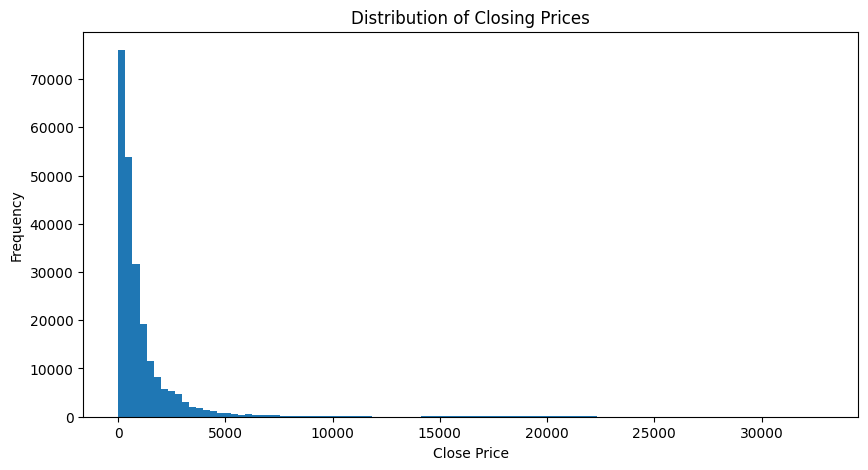

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["Close"], bins=100)
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.title("Distribution of Closing Prices")
plt.show()

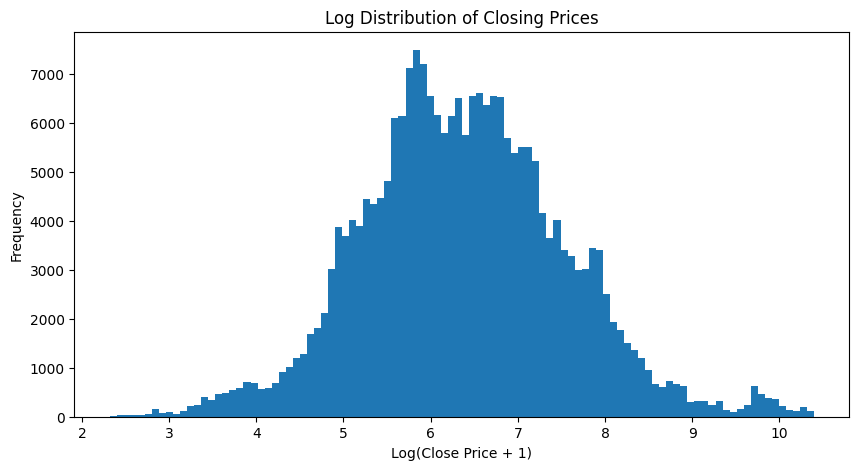

In [ ]:
# Tumhare dataset mein different stocks hain, isliye Close distribution naturally heavily skewed ho sakta hai. ₹100 stock aur ₹3000
# stock ko ek hi distribution mein compare karna perfect nahi hai.
import numpy as np

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df["Close"]), bins=100)
plt.xlabel("Log(Close Price + 1)")
plt.ylabel("Frequency")
plt.title("Log Distribution of Closing Prices")
plt.show()

In [ ]:
# 1. Volume Distribution
df["Volume"].describe()

,Volume
count,2.351920e+05
mean,3.045903e+06
std,7.333981e+06
min,3.000000e+00
25%,2.190095e+05
50%,1.010938e+06
75%,3.019851e+06
max,4.810589e+08


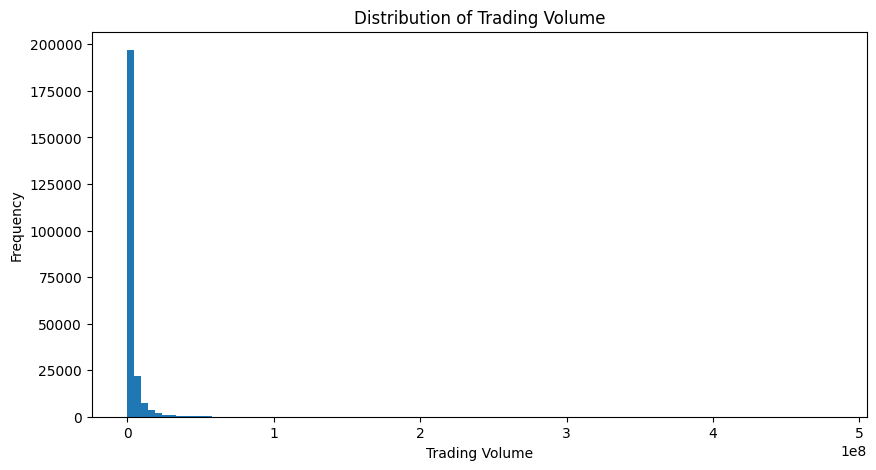

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["Volume"], bins=100)
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Trading Volume")
plt.show()

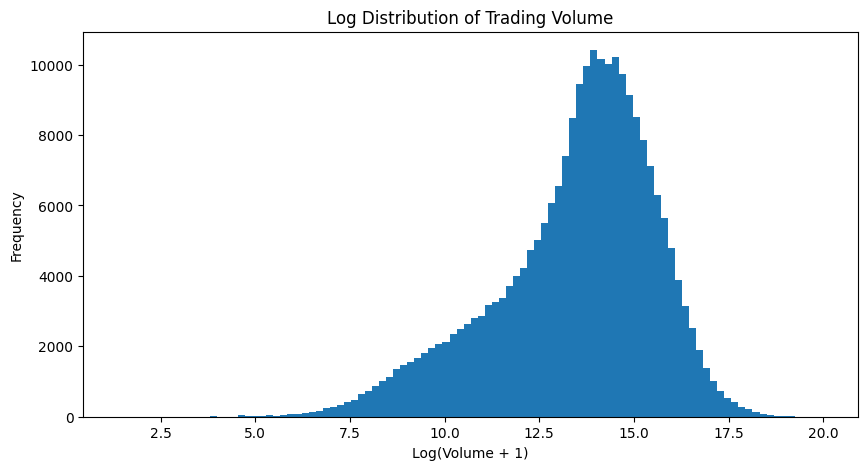

In [ ]:
#  volume generally right squed hota hai
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df["Volume"]), bins=100)
plt.xlabel("Log(Volume + 1)")
plt.ylabel("Frequency")
plt.title("Log Distribution of Trading Volume")
plt.show()

In [ ]:
# 3. Top 10 highest-volume observations
df.nlargest(10, "Volume")[
    ["Date", "Symbol", "Close", "Volume"]
]

,Date,Symbol,Close,Volume
66947,2007-10-05,POWERGRID,100.60,481058927.0
86224,2010-11-04,COALINDIA,342.55,479716245.0
386249,2021-01-12,TATAMOTORS,237.80,390577839.0
386257,2021-01-22,TATAMOTORS,289.35,316008609.0
459415,2019-11-26,ICICIBANK,510.70,286857658.0
68488,2013-12-19,POWERGRID,99.25,286173629.0
386256,2021-01-21,TATAMOTORS,290.60,283614463.0
94042,2020-12-24,VEDL,162.85,270968028.0
27772,2015-04-21,SUNPHARMA,952.20,265709391.0
98563,2017-10-25,SBIN,324.90,262677081.0


In [ ]:
# price outlier
df.nlargest(10, "Close")[
    ["Date", "Symbol", "Close"]
]


,Date,Symbol,Close
371153,2001-09-17,INDUSINDBK,9.15
371169,2001-10-10,INDUSINDBK,9.40
371167,2001-10-08,INDUSINDBK,9.50
371170,2001-10-11,INDUSINDBK,9.60
371158,2001-09-24,INDUSINDBK,9.65
371159,2001-09-25,INDUSINDBK,9.65
371165,2001-10-04,INDUSINDBK,9.65
371166,2001-10-05,INDUSINDBK,9.65
371168,2001-10-09,INDUSINDBK,9.65
371171,2001-10-12,INDUSINDBK,9.65


In [ ]:
df.nsmallest(10, "Close")[
    ["Date", "Symbol", "Close"]
]

,Date,Symbol,Close
371153,2001-09-17,INDUSINDBK,9.15
371169,2001-10-10,INDUSINDBK,9.40
371167,2001-10-08,INDUSINDBK,9.50
371170,2001-10-11,INDUSINDBK,9.60
371158,2001-09-24,INDUSINDBK,9.65
371159,2001-09-25,INDUSINDBK,9.65
371165,2001-10-04,INDUSINDBK,9.65
371166,2001-10-05,INDUSINDBK,9.65
371168,2001-10-09,INDUSINDBK,9.65
371171,2001-10-12,INDUSINDBK,9.65


In [ ]:
# 5. Volume by stock
df.groupby("Symbol")["Volume"].mean().sort_values(
    ascending=False
).head(10)

,Volume
Symbol,
VEDL,1.564060e+07
TATAMOTORS,1.247240e+07
SBIN,1.003930e+07
HINDALCO,9.282843e+06
ICICIBANK,8.224631e+06
NTPC,7.226587e+06
ITC,7.173165e+06
TATASTEEL,6.975771e+06
AXISBANK,6.916522e+06


**Time-Series Analysis**

In [ ]:
# Iska goal hai time ke saath price, return, volume aur volatility ka behavior samajhna.

# Step 1: Data chronological order mein
df = df.sort_values(["Symbol", "Date"]).copy()

In [ ]:
# Step 2: Monthly analysis
#     Daily data ko monthly level par aggregate karo:

monthly = df.set_index("Date").resample("ME").agg(
    Avg_Close=("Close", "mean"),
    Avg_Volume=("Volume", "mean"),
    Avg_Return=("Daily_Return", "mean")
)
monthly.head()

,Avg_Close,Avg_Volume,Avg_Return
Date,,,
2000-01-31,985.506899,848393.878338,0.110653
2000-02-29,1016.286625,600212.369748,-0.095593
2000-03-31,1003.735536,624773.400881,-0.285200
2000-04-30,912.327407,969931.253704,-0.678075
2000-05-31,728.820833,696913.366667,0.004195


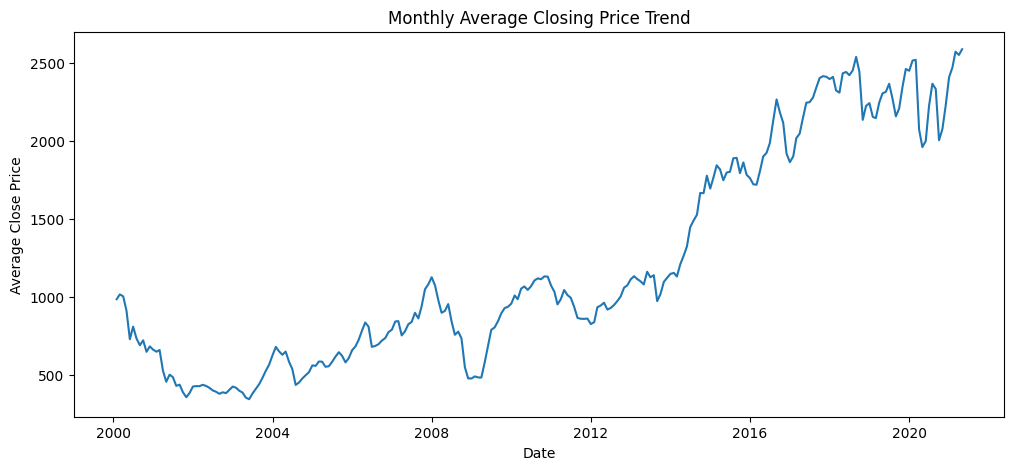

In [ ]:
# Step 3: Monthly price trend

plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly["Avg_Close"])

plt.xlabel("Date")
plt.ylabel("Average Close Price")
plt.title("Monthly Average Closing Price Trend")

plt.show()

# Ye tumhe long-term price movement ka overall picture dega.

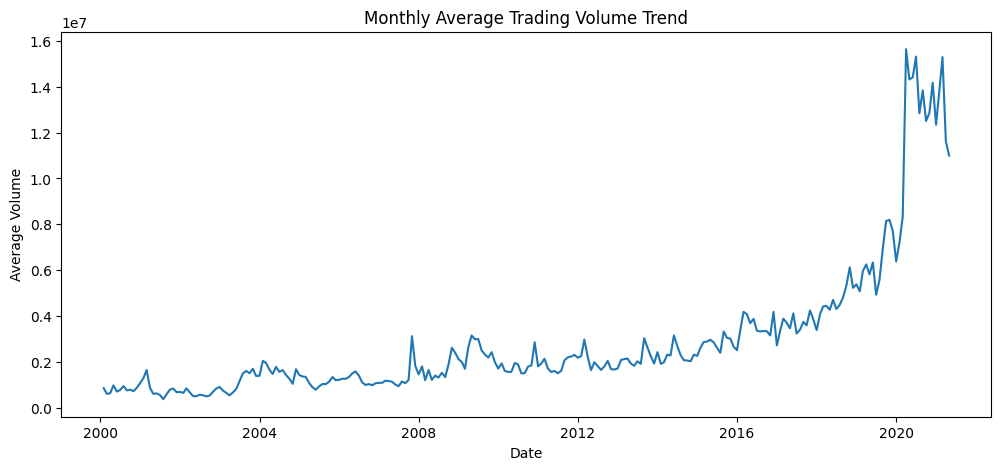

In [ ]:
# Step 4: Monthly trading volume trend
plt.figure(figsize=(12, 5))


plt.plot(monthly.index, monthly["Avg_Volume"])


plt.xlabel("Date")
plt.ylabel("Average Volume")
plt.title("Monthly Average Trading Volume Trend")


plt.show()

# Isse trading activity ka evolution dikhega.


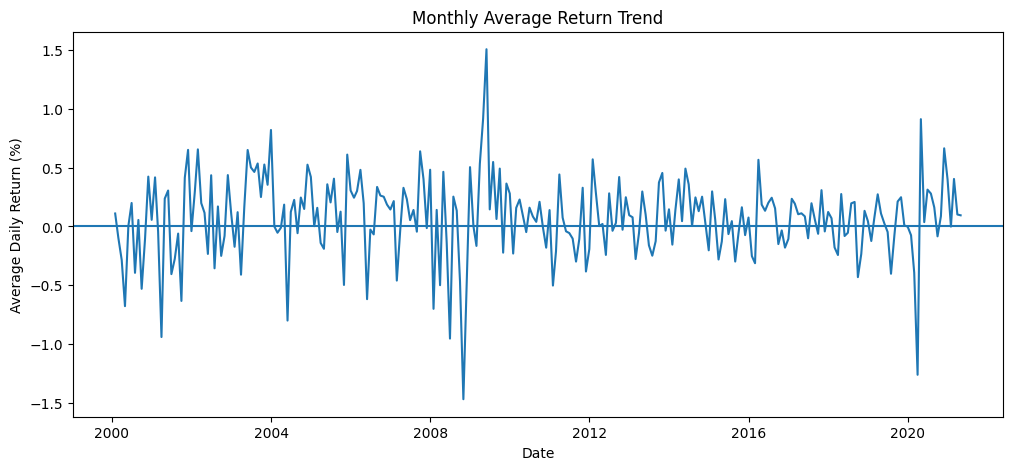

In [ ]:
# Step 5: Monthly return trend
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly["Avg_Return"])

plt.axhline(0)
plt.xlabel("Date")
plt.ylabel("Average Daily Return (%)")
plt.title("Monthly Average Return Trend")

plt.show()

# Zero line ke upar = positive average return, neeche = negative.


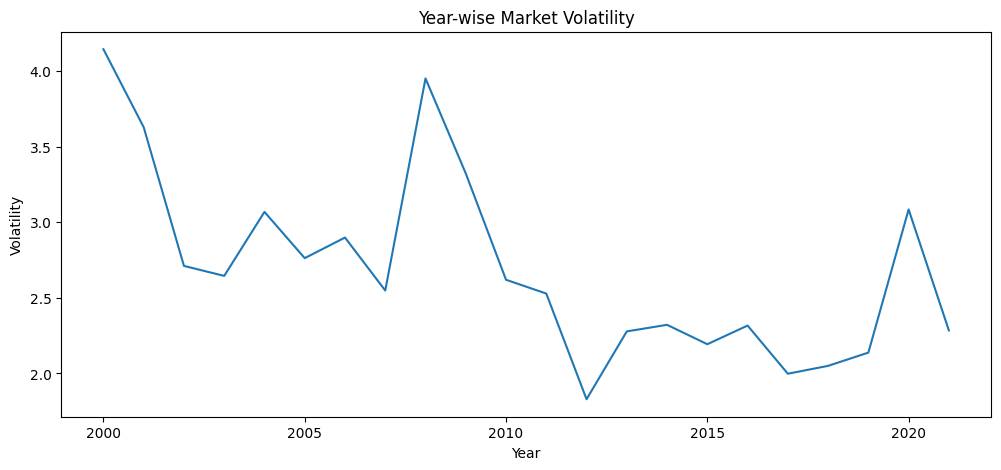

In [ ]:
# Step 6: Yearly volatility
yearly_volatility = df.groupby(
    df["Date"].dt.year
)["Daily_Return"].std()


plt.figure(figsize=(12, 5))


plt.plot(
    yearly_volatility.index,
    yearly_volatility.values
)


plt.xlabel("Year")
plt.ylabel("Volatility")
plt.title("Year-wise Market Volatility")


plt.show()

# Ye identify karega ki kaunse years mein market zyada volatile tha.


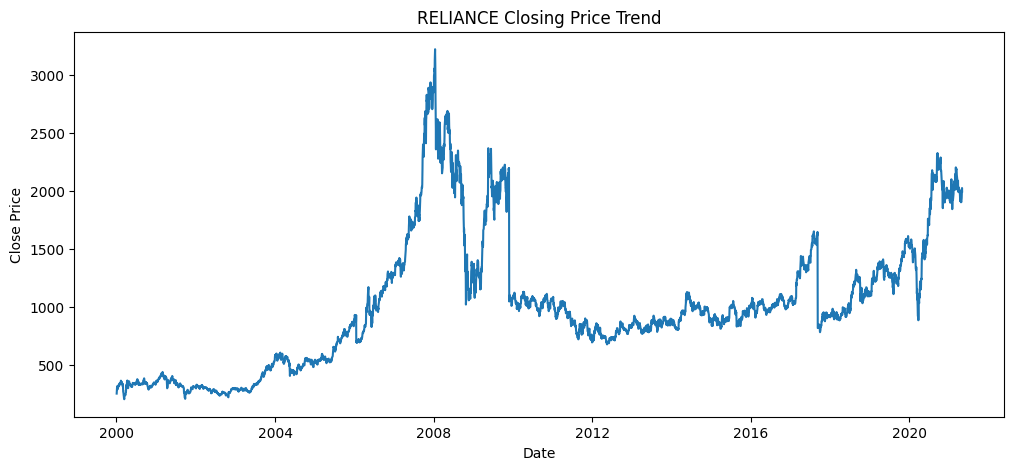

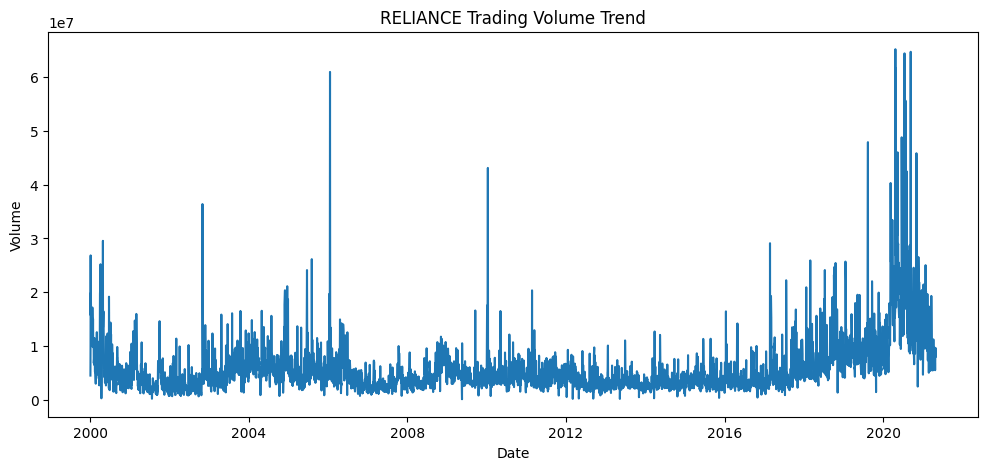

In [ ]:
# Step 7: Individual stock ka time series
# Overall dataset ke saath ek specific stock ka trend
#  bhi analyze karna important hai.
# Example RELIANCE:

stock = df[df["Symbol"] == "RELIANCE"].sort_values("Date")

# Price:

plt.figure(figsize=(12, 5))


plt.plot(stock["Date"], stock["Close"])


plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("RELIANCE Closing Price Trend")


plt.show()

# Volume:

plt.figure(figsize=(12, 5))


plt.plot(stock["Date"], stock["Volume"])


plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("RELIANCE Trading Volume Trend")


plt.show()

# Tumhare report mein:
  # "Time-series analysis was performed to identify
  #  long-term price trends, changes in trading activity,
  #  return patterns and periods of elevated volatility."

## *TimeSeries Analysis*

In [ ]:
# Time-Series Analysis ko properly complete karte hain. Tumhare dataset mein 50 stocks aur 2000–2021 ka data hai,
#  isliye time-series analysis ko overall + individual stock dono level par karna best hai.

# Step 1: Date ko sort karo
df = df.sort_values(["Symbol", "Date"]).copy()

In [ ]:
# Step 2: Monthly summary banao
monthly = df.set_index("Date").resample("ME").agg(
    Avg_Close=("Close", "mean"),
    Avg_Volume=("Volume", "mean"),
    Avg_Return=("Daily_Return", "mean")
)

monthly.head()

,Avg_Close,Avg_Volume,Avg_Return
Date,,,
2000-01-31,985.506899,848393.878338,0.110653
2000-02-29,1016.286625,600212.369748,-0.095593
2000-03-31,1003.735536,624773.400881,-0.285200
2000-04-30,912.327407,969931.253704,-0.678075
2000-05-31,728.820833,696913.366667,0.004195


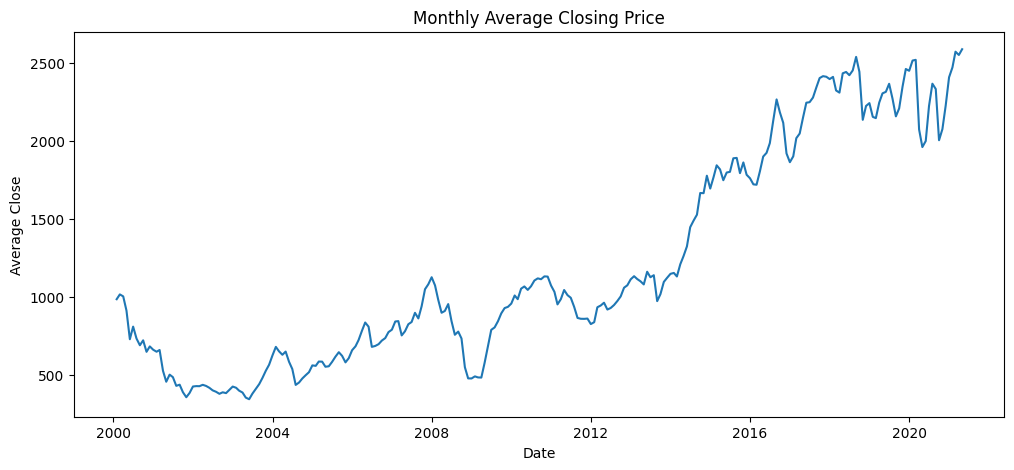

In [ ]:
# Step 3: Closing price trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["Avg_Close"])
plt.title("Monthly Average Closing Price")
plt.xlabel("Date")
plt.ylabel("Average Close")
plt.show()

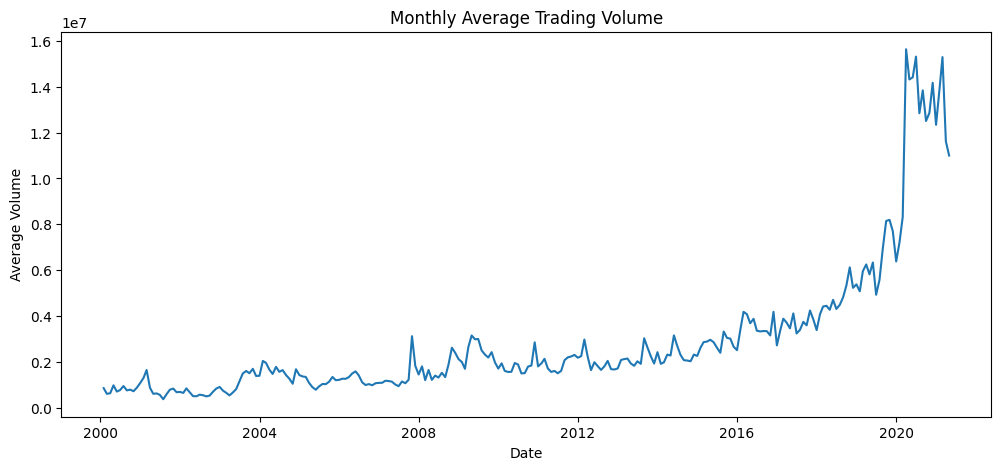

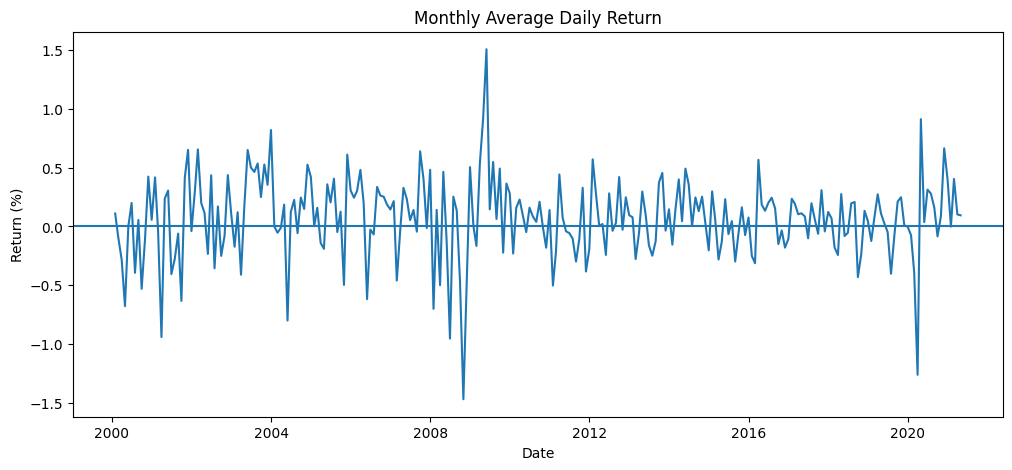

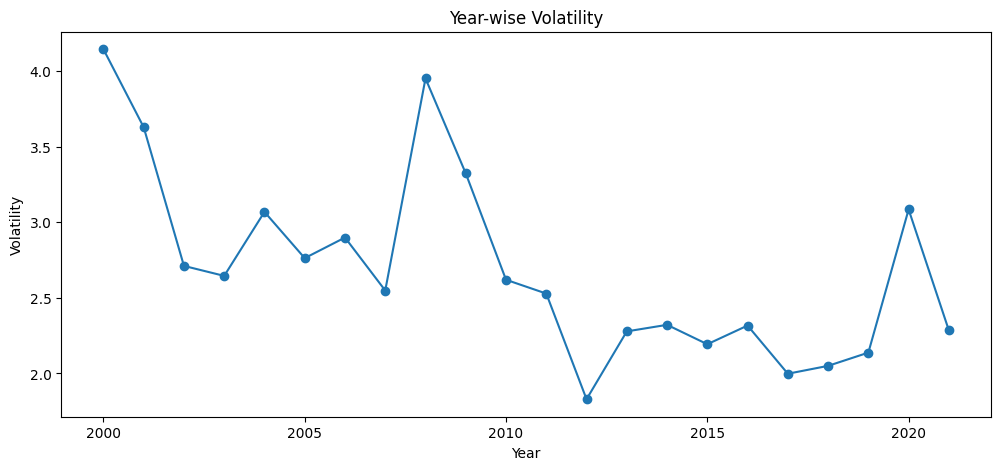

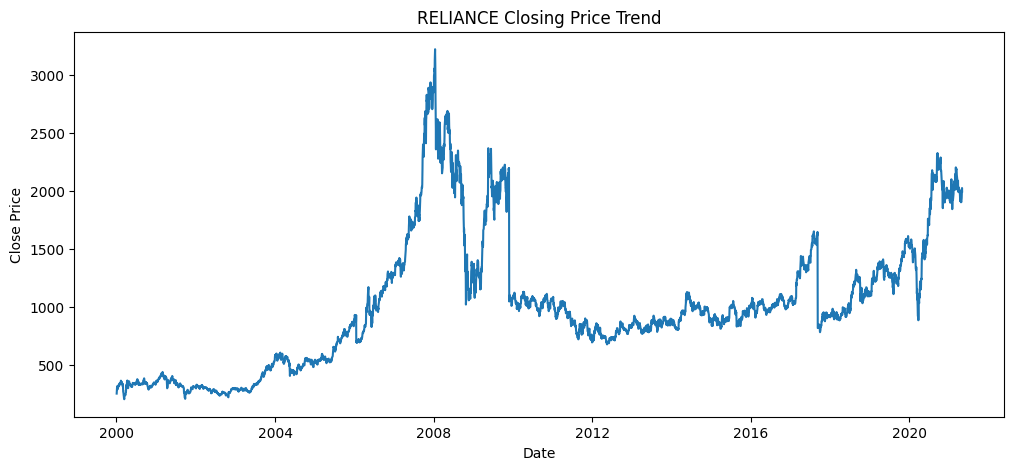

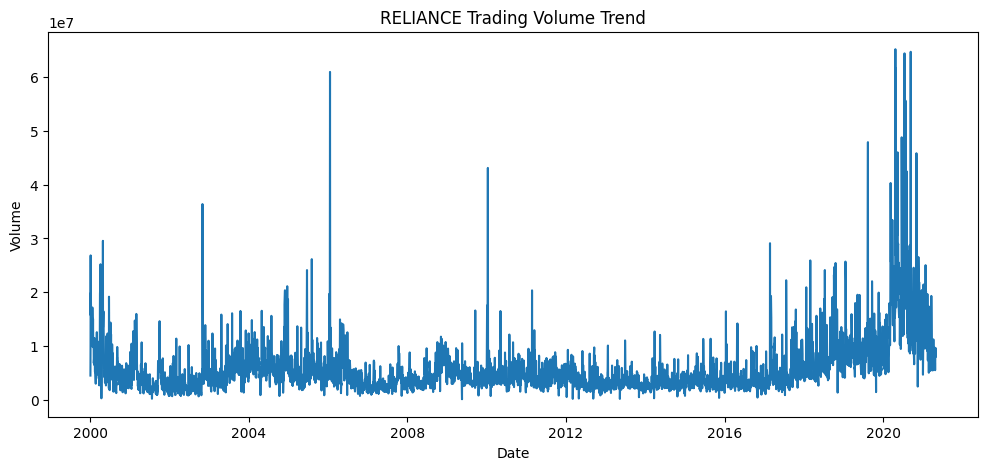

In [ ]:
# Step 4: Trading volume trend
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["Avg_Volume"])
plt.title("Monthly Average Trading Volume")
plt.xlabel("Date")
plt.ylabel("Average Volume")
plt.show()
# Step 5: Monthly return trend
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["Avg_Return"])
plt.axhline(0)
plt.title("Monthly Average Daily Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.show()
# Step 6: Year-wise volatility
yearly_volatility = df.groupby(
    df["Date"].dt.year
)["Daily_Return"].std()


plt.figure(figsize=(12,5))
plt.plot(yearly_volatility.index, yearly_volatility.values, marker="o")
plt.title("Year-wise Volatility")
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.show()
# Step 7: Individual stock time series

# For example, RELIANCE:

stock = df[df["Symbol"] == "RELIANCE"].sort_values("Date")

# Price trend:

plt.figure(figsize=(12,5))
plt.plot(stock["Date"], stock["Close"])
plt.title("RELIANCE Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# Volume trend:

plt.figure(figsize=(12,5))
plt.plot(stock["Date"], stock["Volume"])
plt.title("RELIANCE Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [ ]:
df.info()

## *Correlation Analysis*

In [ ]:

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_parquet(
    "/content/drive/MyDrive/Nifty50_Project/nifty50_master.parquet"
)

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(470434, 19)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Stock,Company Name,Industry,ISIN Code
0,2000-01-03,TISCO,EQ,142.35,148.00,153.2,146.10,152.50,152.45,150.92,2003185.0,3.023164e+13,NaN,NaN,NaN,TATASTEEL,None,None,None
1,2000-01-04,TISCO,EQ,152.45,150.10,153.0,143.05,151.95,150.80,151.03,1555136.0,2.348785e+13,NaN,NaN,NaN,TATASTEEL,None,None,None
2,2000-01-05,TISCO,EQ,150.80,144.60,162.9,144.60,158.00,156.55,156.85,3840284.0,6.023364e+13,NaN,NaN,NaN,TATASTEEL,None,None,None
3,2000-01-06,TISCO,EQ,156.55,158.95,169.1,158.95,169.00,168.25,167.61,2560449.0,4.291530e+13,NaN,NaN,NaN,TATASTEEL,None,None,None
4,2000-01-07,TISCO,EQ,168.25,173.40,179.0,166.30,170.55,171.95,173.89,3641691.0,6.332459e+13,NaN,NaN,NaN,TATASTEEL,None,None,None


In [ ]:
# 1. Correlation matrix
corr = df[
    [
        "Prev Close",
        "Open",
        "High",
        "Low",
        "Last",
        "Close",
        "VWAP",
        "Volume",
        "Turnover",
        "Daily_Return"
    ]
].corr()

corr

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Daily_Return
Prev Close,1.000000,0.999718,0.999616,0.999601,0.999505,0.999518,0.999622,-0.118742,0.052888,-0.005304
Open,0.999718,1.000000,0.999857,0.999863,0.999748,0.999761,0.999867,-0.118779,0.052704,-0.000573
High,0.999616,0.999857,1.000000,0.999790,0.999881,0.999892,0.999937,-0.118595,0.053697,0.002152
Low,0.999601,0.999863,0.999790,1.000000,0.999868,0.999878,0.999929,-0.118914,0.052144,0.002147
Last,0.999505,0.999748,0.999881,0.999868,1.000000,0.999991,0.999950,-0.118713,0.053110,0.004556
Close,0.999518,0.999761,0.999892,0.999878,0.999991,1.000000,0.999963,-0.118705,0.053106,0.004496
VWAP,0.999622,0.999867,0.999937,0.999929,0.999950,0.999963,1.000000,-0.118757,0.053013,0.002881
Volume,-0.118742,-0.118779,-0.118595,-0.118914,-0.118713,-0.118705,-0.118757,1.000000,0.629582,0.024360
Turnover,0.052888,0.052704,0.053697,0.052144,0.053110,0.053106,0.053013,0.629582,1.000000,0.023469
Daily_Return,-0.005304,-0.000573,0.002152,0.002147,0.004556,0.004496,0.002881,0.024360,0.023469,1.000000


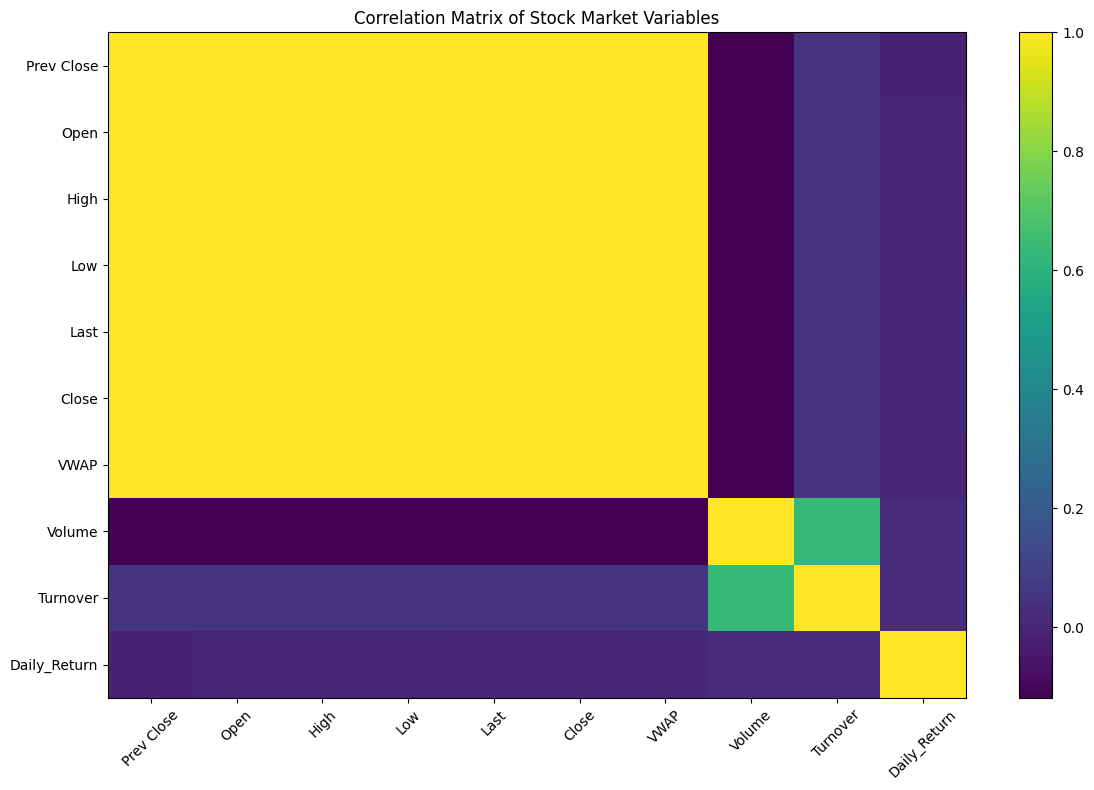

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix of Stock Market Variables")

plt.tight_layout()
plt.show()

In [ ]:
corr["Daily_Return"].sort_values(ascending=False)

,Daily_Return
Daily_Return,1.000000
Volume,0.024360
Turnover,0.023469
Last,0.004556
Close,0.004496
VWAP,0.002881
High,0.002152
Low,0.002147
Open,-0.000573
Prev Close,-0.005304


## *Trading Activity Analysis*

In [ ]:
# 1. Average volume by stock
volume_by_stock = (
    df.groupby("Symbol")["Volume"]
      .mean()
      .sort_values(ascending=False)
)

volume_by_stock.head(10)

,Volume
Symbol,
VEDL,1.564060e+07
TATAMOTORS,1.247240e+07
SBIN,1.003930e+07
HINDALCO,9.282843e+06
ICICIBANK,8.224631e+06
NTPC,7.226587e+06
ITC,7.173165e+06
TATASTEEL,6.975771e+06
AXISBANK,6.916522e+06


In [ ]:
# 2. Total volume by stock
total_volume = (
    df.groupby("Symbol")["Volume"]
      .sum()
      .sort_values(ascending=False)
)

total_volume.head(10)


,Volume
Symbol,
TATAMOTORS,1.074373e+11
SBIN,1.065371e+11
ICICIBANK,8.727978e+10
ITC,7.612163e+10
HINDALCO,6.288198e+10
RELIANCE,5.924709e+10
NTPC,5.908458e+10
TATASTEEL,5.372739e+10
ONGC,4.910569e+10


In [ ]:
# 4. Most active trading days
df.nlargest(10, "Volume")[
    ["Date", "Symbol", "Close", "Volume", "Turnover"]
]

,Date,Symbol,Close,Volume,Turnover
66947,2007-10-05,POWERGRID,100.60,481058927.0,4.930561e+15
288141,2007-10-05,POWERGRID,100.60,481058927.0,4.930561e+15
86224,2010-11-04,COALINDIA,342.55,479716245.0,1.570040e+16
171510,2010-11-04,COALINDIA,342.55,479716245.0,1.570040e+16
317636,2021-01-12,TATAMOTORS,237.80,390577839.0,9.302950e+15
386299,2021-01-12,TATAMOTORS,237.80,390577839.0,9.302950e+15
317644,2021-01-22,TATAMOTORS,289.35,316008609.0,9.365671e+15
386307,2021-01-22,TATAMOTORS,289.35,316008609.0,9.365671e+15
231785,2019-11-26,ICICIBANK,510.70,286857658.0,1.461959e+16
459465,2019-11-26,ICICIBANK,510.70,286857658.0,1.461959e+16


In [ ]:
# 5. Deliverable percentage
delivery_by_stock = (
    df.groupby("Symbol")["%Deliverble"]
      .mean()
      .sort_values(ascending=False)
)

delivery_by_stock.head(10)

# Why this matters

# This section lets you answer questions such as:
# Which stocks had the highest trading activity?
# Which stocks had the highest average deliverable percentage?
# Which stocks consistently attracted high market participation?

,%Deliverble
Symbol,
BAJAUTOFIN,0.763764
SHREECEM,0.682339
UNIPHOS,0.663740
NESTLEIND,0.662074
HDFC,0.653088
BRITANNIA,0.644524
HINDUNILVR,0.628353
ASIANPAINT,0.625572
INFY,0.612327


## **EDA**

In [ ]:
# 1. Average Volume by Stock
volume_by_stock = (
    df.groupby("Symbol")["Volume"]
      .mean()
      .sort_values(ascending=False)
)

volume_by_stock.head(10)

,Volume
Symbol,
VEDL,1.564060e+07
TATAMOTORS,1.247240e+07
SBIN,1.003930e+07
HINDALCO,9.282843e+06
ICICIBANK,8.224631e+06
NTPC,7.226587e+06
ITC,7.173165e+06
TATASTEEL,6.975771e+06
AXISBANK,6.916522e+06


In [ ]:
# 2. Total Volume by Stock
total_volume = (
    df.groupby("Symbol")["Volume"]
      .sum()
      .sort_values(ascending=False)
)

total_volume.head(10)

,Volume
Symbol,
TATAMOTORS,1.074373e+11
SBIN,1.065371e+11
ICICIBANK,8.727978e+10
ITC,7.612163e+10
HINDALCO,6.288198e+10
RELIANCE,5.924709e+10
NTPC,5.908458e+10
TATASTEEL,5.372739e+10
ONGC,4.910569e+10


In [ ]:
# 3. Average Turnover by Stock
turnover_by_stock = (
    df.groupby("Symbol")["Turnover"]
      .mean()
      .sort_values(ascending=False)
)

turnover_by_stock.head(10)

,Turnover
Symbol,
RELIANCE,6.076715e+14
INFY,5.147948e+14
AXISBANK,4.238762e+14
SBIN,4.136854e+14
ICICIBANK,3.759336e+14
BAJFINANCE,3.564173e+14
TATAMOTORS,3.352950e+14
TATASTEEL,3.245291e+14
TCS,2.952102e+14


In [ ]:
# 4. Highest Trading-Volume Days
df.nlargest(10, "Volume")[
    ["Date", "Symbol", "Close", "Volume", "Turnover"]
]

,Date,Symbol,Close,Volume,Turnover
66947,2007-10-05,POWERGRID,100.60,481058927.0,4.930561e+15
288141,2007-10-05,POWERGRID,100.60,481058927.0,4.930561e+15
86224,2010-11-04,COALINDIA,342.55,479716245.0,1.570040e+16
171510,2010-11-04,COALINDIA,342.55,479716245.0,1.570040e+16
317636,2021-01-12,TATAMOTORS,237.80,390577839.0,9.302950e+15
386299,2021-01-12,TATAMOTORS,237.80,390577839.0,9.302950e+15
317644,2021-01-22,TATAMOTORS,289.35,316008609.0,9.365671e+15
386307,2021-01-22,TATAMOTORS,289.35,316008609.0,9.365671e+15
231785,2019-11-26,ICICIBANK,510.70,286857658.0,1.461959e+16
459465,2019-11-26,ICICIBANK,510.70,286857658.0,1.461959e+16


In [ ]:
# 5. Deliverable Percentage
df["%Deliverble"].describe()

,%Deliverble
count,438230.000000
mean,0.502997
std,0.190019
min,0.023600
25%,0.364700
50%,0.511000
75%,0.638400
max,1.000000


In [ ]:
# 6. Average Deliverable Percentage by Stock
delivery_by_stock = (
    df.groupby("Symbol")["%Deliverble"]
      .mean()
      .sort_values(ascending=False)
)

delivery_by_stock.head(10)

,%Deliverble
Symbol,
BAJAUTOFIN,0.763764
SHREECEM,0.682339
UNIPHOS,0.663740
NESTLEIND,0.662074
HDFC,0.653088
BRITANNIA,0.644524
HINDUNILVR,0.628353
ASIANPAINT,0.625572
INFY,0.612327


In [ ]:
# -------------------------->>>>

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [ ]:
# Step 1 only: Overall Dataset Summary
print("Total Rows:", len(df))
print("Total Stocks:", df["Symbol"].nunique())
print("Date Range:", df["Date"].min(), "to", df["Date"].max())
print("Industries:", df["Industry"].nunique())

Total Rows: 470434
Total Stocks: 66
Date Range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00
Industries: 13


In [ ]:
# Step 2: Stock-level final insights
stock_summary = (
    df.groupby("Symbol")
      .agg(
          Trading_Days=("Date", "count"),
          Avg_Close=("Close", "mean"),
          Avg_Volume=("Volume", "mean"),
          Avg_Return=("Daily_Return", "mean"),
          Volatility=("Daily_Return", "std")
      )
      .sort_values("Avg_Return", ascending=False)
)

stock_summary.head(10)

,Trading_Days,Avg_Close,Avg_Volume,Avg_Return,Volatility
Symbol,,,,,
BHARTI,2178,155.404821,1.673337e+06,0.116546,1.995889
UTIBANK,3824,163.126203,2.879499e+05,0.105853,2.228072
BAJAUTOFIN,5222,196.659747,1.899630e+04,0.077606,2.254056
BAJFINANCE,5248,2627.858937,1.201285e+06,0.077559,2.080252
SHREECEM,9970,6565.809539,2.507495e+04,0.075837,1.737101
EICHERMOT,10602,6751.063167,9.628430e+04,0.068844,2.140674
SESAGOA,6870,609.933581,1.810788e+06,0.068447,2.769686
BAJAJFINSV,6402,2758.657451,2.315312e+05,0.064097,1.786659
INDUSINDBK,9970,494.322698,2.351251e+06,0.061067,2.259093


In [ ]:
stock_summary.tail(10)

# This will give us:

# Top 10 stocks by average return
# Bottom 10 stocks by average return
# Trading days
# Average price
# Average volume
# Volatility

,Trading_Days,Avg_Close,Avg_Volume,Avg_Return,Volatility
Symbol,,,,,
IOC,10612,318.582614,3.188201e+06,0.009475,1.874892
INFOSYSTCH,5740,3323.156028,1.030852e+06,0.006985,2.375921
INFY,4872,1708.548912,4.498399e+06,0.004638,1.782629
HINDALC0,3838,702.349088,1.092017e+06,0.001779,2.163289
ZEETELE,3592,225.774415,4.674488e+06,-0.004021,2.834802
COALINDIA,5196,287.953464,5.617118e+06,-0.009373,1.328216
HINDLEVER,3786,345.307818,1.975032e+06,-0.016409,2.134071
MUNDRAPORT,2046,456.769159,8.090038e+05,-0.029566,2.910170
JSWSTL,246,302.411789,2.990642e+05,-0.100386,1.525344


In [ ]:
# Step 3: Remove metadata-only symbols from the analysis
analysis_df = df[df["Close"].notna()].copy()

print("Rows:", len(analysis_df))
print("Stocks:", analysis_df["Symbol"].nunique())

# This ensures our final analysis is based only on actual market observations.
analysis_df.groupby("Symbol")["Date"].count().sort_values().head(10)

Rows: 470384
Stocks: 65


,Date
Symbol,
JSWSTL,246
SSLT,776
KOTAKMAH,1004
TELCO,1998
MUNDRAPORT,2046
BHARTI,2178
TISCO,2910
VEDL,2964
ZEETELE,3592


In [ ]:
# Step 4: Recalculate stock summary
stock_summary = (
    analysis_df.groupby("Symbol")
    .agg(
        Trading_Days=("Date", "count"),
        Avg_Close=("Close", "mean"),
        Avg_Volume=("Volume", "mean"),
        Avg_Return=("Daily_Return", "mean"),
        Volatility=("Daily_Return", "std")
    )
    .sort_values("Avg_Return", ascending=False)
)

stock_summary.head(10)

,Trading_Days,Avg_Close,Avg_Volume,Avg_Return,Volatility
Symbol,,,,,
BHARTI,2178,155.404821,1.673337e+06,0.116546,1.995889
UTIBANK,3824,163.126203,2.879499e+05,0.105853,2.228072
BAJAUTOFIN,5222,196.659747,1.899630e+04,0.077606,2.254056
BAJFINANCE,5248,2627.858937,1.201285e+06,0.077574,2.080450
SHREECEM,9970,6565.809539,2.507495e+04,0.075845,1.737188
EICHERMOT,10602,6751.063167,9.628430e+04,0.068851,2.140775
SESAGOA,6870,609.933581,1.810788e+06,0.068447,2.769686
BAJAJFINSV,6402,2758.657451,2.315312e+05,0.064107,1.786799
INDUSINDBK,9970,494.322698,2.351251e+06,0.061073,2.259206


In [ ]:
# Step 4: Industry-Level Final Insights
industry_summary = (
    analysis_df.groupby("Industry")
    .agg(
        Trading_Days=("Date", "count"),
        Avg_Return=("Daily_Return", "mean"),
        Volatility=("Daily_Return", "std"),
        Avg_Volume=("Volume", "mean"),
        Avg_Turnover=("Turnover", "mean"),
        Stocks=("Symbol", "nunique")
    )
    .sort_values("Avg_Return", ascending=False)
)

industry_summary
# Why we're doing this

# We want three final questions answered:

# 1. Which industry had the highest average return?

# 2. Which industry was the most volatile?

# 3. Which industry had the highest trading activity?


,Trading_Days,Avg_Return,Volatility,Avg_Volume,Avg_Turnover,Stocks
Industry,,,,,,


In [ ]:
print(df["Industry"].notna().sum())
print(df["Company Name"].notna().sum())


50
50


In [ ]:
analysis_df["Industry"] = df.loc[analysis_df.index, "Industry"]

In [ ]:
print(df["Industry"].notna().sum())
print(df["Company Name"].notna().sum())


50
50


In [ ]:
# Hum Symbol ke basis par available 50 metadata rows se mapping banayenge.
industry_map = (
    df[df["Industry"].notna()]
    .drop_duplicates("Symbol")
    .set_index("Symbol")["Industry"]
)

In [ ]:
analysis_df["Industry"] = analysis_df["Symbol"].map(industry_map)

In [ ]:
print("Missing Industry:", analysis_df["Industry"].isna().sum())

Missing Industry: 54684


In [ ]:
# Step 1: Check which symbols are missing Industry
missing_industry = (
    analysis_df[analysis_df["Industry"].isna()]["Symbol"]
    .value_counts()
)

missing_industry

,count
Symbol,
SESAGOA,6870
HEROHONDA,5796
INFOSYSTCH,5740
BAJAUTOFIN,5222
UNIPHOS,4858
HINDALC0,3838
UTIBANK,3824
HINDLEVER,3786
ZEETELE,3592


In [ ]:
# Step 2: Create industry analysis dataset
industry_df = analysis_df.dropna(subset=["Industry"]).copy()

print("Rows:", len(industry_df))
print("Stocks:", industry_df["Symbol"].nunique())
print("Missing Industry:", industry_df["Industry"].isna().sum())

Rows: 415700
Stocks: 49
Missing Industry: 0


In [ ]:
industry_summary = (
    industry_df.groupby("Industry")
    .agg(
        Trading_Days=("Date", "count"),
        Avg_Return=("Daily_Return", "mean"),
        Volatility=("Daily_Return", "std"),
        Avg_Volume=("Volume", "mean"),
        Avg_Turnover=("Turnover", "mean"),
        Stocks=("Symbol", "nunique")
    )
    .sort_values("Avg_Return", ascending=False)
)

display(industry_summary)

,Trading_Days,Avg_Return,Volatility,Avg_Volume,Avg_Turnover,Stocks
Industry,,,,,,
FERTILISERS & PESTICIDES,3716,0.052993,1.775856,2.868241e+06,1.527453e+14,1
CEMENT & CEMENT PRODUCTS,28862,0.051766,1.677733,2.565819e+05,4.618627e+13,3
SERVICES,4598,0.050407,1.700828,3.909287e+06,1.403270e+14,1
FINANCIAL SERVICES,79822,0.047723,1.993328,4.092180e+06,2.755490e+14,9
AUTOMOBILE,49902,0.040835,1.865246,2.823390e+06,1.652824e+14,6
CONSUMER GOODS,54884,0.037736,1.660798,2.007288e+06,9.788134e+13,6
METALS,30378,0.030008,2.018253,7.027916e+06,1.961151e+14,5
CONSTRUCTION,8368,0.027512,1.823428,1.917127e+06,2.644572e+14,1
IT,41632,0.021038,2.038758,2.127041e+06,1.936411e+14,5


# final cleanup, validation, feature columns, aur files save karni hain.

In [ ]:
# 1. Final analysis dataset check
print("Rows:", len(analysis_df))
print("Columns:", len(analysis_df.columns))
print("Stocks:", analysis_df["Symbol"].nunique())
print("Date:", analysis_df["Date"].min(), "to", analysis_df["Date"].max())

Rows: 470384
Columns: 20
Stocks: 65
Date: 2000-01-03 00:00:00 to 2021-04-30 00:00:00


In [ ]:
# 2. Final missing-value check
analysis_df.isnull().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


In [ ]:
# 3. Final data-quality check
print("Duplicate rows:", analysis_df.duplicated().sum())

print("High < Low:", (analysis_df["High"] < analysis_df["Low"]).sum())
print("Negative Volume:", (analysis_df["Volume"] < 0).sum())
print("Negative Close:", (analysis_df["Close"] < 0).sum())

Duplicate rows: 0
High < Low: 0
Negative Volume: 0
Negative Close: 0


In [ ]:
# 4. Check Daily_Return
print("Infinite returns:", analysis_df["Daily_Return"].isin([float("inf"), float("-inf")]).sum())
print("Missing returns:", analysis_df["Daily_Return"].isna().sum())

Infinite returns: 0
Missing returns: 65


In [ ]:
# 5. Add useful calendar features
analysis_df["Year"] = analysis_df["Date"].dt.year
analysis_df["Month"] = analysis_df["Date"].dt.month
analysis_df["Month_Name"] = analysis_df["Date"].dt.month_name()
analysis_df["Quarter"] = analysis_df["Date"].dt.quarter

In [ ]:
# 6. Final dataset save karo
powerbi_df = analysis_df.copy()

powerbi_path = "/content/drive/MyDrive/Nifty50_Project/nifty50_powerbi.csv"

powerbi_df.to_csv(powerbi_path, index=False)

print("Saved successfully!")
print(powerbi_path)

Saved successfully!
/content/drive/MyDrive/Nifty50_Project/nifty50_powerbi.csv


In [ ]:
ml_path = "/content/drive/MyDrive/Nifty50_Project/nifty50_clean_final.parquet"

analysis_df.to_parquet(ml_path, index=False)

print("ML dataset saved!")
print(ml_path)

ML dataset saved!
/content/drive/MyDrive/Nifty50_Project/nifty50_clean_final.parquet
